# LESSON 13
# Библиотека Open CV

**Для каждой задачи рекомендуется:**

* Реализовать базовую версию

* Добавить настройку параметров

* Визуализировать результаты

* Сравнить разные методы/алгоритмы

In [3]:
import numpy as np
import cv2

import matplotlib.pyplot as plt

## Практические мини-проекты

1. Фоторедактор: инструменты для обрезки, поворота, изменения яркости, фильтры

2. Детектор лиц с масками: определить, надета ли маска на человеке

3. Распознавание жестов: детектировать пальцы и жесты с веб-камеры

4. Сканер документов: автоматическое определение границ и исправление перспективы

5. Виртуальная клавиатура: рисование в воздухе с отслеживанием пальца

6. Пульсометр: измерение пульса по изменению цвета лица на видео

7. Анализ дорожного движения: подсчет машин и определение скорости

8. Автоматическое создание аватара: обрезка лица и наложение эффектов

## Фоторедактор: инструменты для обрезки, поворота, изменения яркости, фильтры

In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import os
from tkinter import filedialog, Tk
import tkinter as tk
from tkinter import ttk, messagebox
from PIL import Image, ImageTk
import time

# ============================================
# 0. ПОДГОТОВКА
# ============================================

print("="*50)
print("ФОТОРЕДАКТОР - Инструменты для обработки изображений")
print("="*50)

# Создаем папку для сохранения результатов
save_dir = 'edited_photos'
os.makedirs(save_dir, exist_ok=True)

# ============================================
# 1. КЛАСС ФИЛЬТРОВ И ИНСТРУМЕНТОВ
# ============================================

class PhotoEditor:
    """
    Класс с инструментами для редактирования фото
    """
    
    # ========== 1.1 БАЗОВЫЕ ОПЕРАЦИИ ==========
    
    @staticmethod
    def resize(image, width=None, height=None, scale=None):
        """
        Изменение размера изображения
        width, height - новые размеры в пикселях
        scale - масштаб (например 0.5 - уменьшить в 2 раза)
        """
        h, w = image.shape[:2]
        
        if scale is not None:
            new_w = int(w * scale)
            new_h = int(h * scale)
        elif width is not None and height is not None:
            new_w, new_h = width, height
        elif width is not None:
            new_w = width
            new_h = int(h * width / w)
        elif height is not None:
            new_h = height
            new_w = int(w * height / h)
        else:
            return image.copy()
        
        return cv2.resize(image, (new_w, new_h), interpolation=cv2.INTER_LINEAR)
    
    @staticmethod
    def rotate(image, angle, center=None):
        """
        Поворот изображения на заданный угол
        angle - угол в градусах (положительный = против часовой стрелки)
        """
        h, w = image.shape[:2]
        
        if center is None:
            center = (w // 2, h // 2)
        
        # Создаем матрицу поворота
        rotation_matrix = cv2.getRotationMatrix2D(center, angle, 1.0)
        
        # Вычисляем новые размеры для сохранения всего изображения
        cos = abs(rotation_matrix[0, 0])
        sin = abs(rotation_matrix[0, 1])
        new_w = int((h * sin) + (w * cos))
        new_h = int((h * cos) + (w * sin))
        
        # Корректируем матрицу для смещения
        rotation_matrix[0, 2] += (new_w / 2) - center[0]
        rotation_matrix[1, 2] += (new_h / 2) - center[1]
        
        return cv2.warpAffine(image, rotation_matrix, (new_w, new_h))
    
    @staticmethod
    def flip(image, direction='horizontal'):
        """
        Отражение изображения
        direction: 'horizontal', 'vertical', 'both'
        """
        if direction == 'horizontal':
            return cv2.flip(image, 1)
        elif direction == 'vertical':
            return cv2.flip(image, 0)
        elif direction == 'both':
            return cv2.flip(image, -1)
        return image.copy()
    
    @staticmethod
    def crop(image, x, y, w, h):
        """
        Обрезка изображения
        x, y - координаты верхнего левого угла
        w, h - ширина и высота области
        """
        return image[y:y+h, x:x+w].copy()
    
    # ========== 1.2 НАСТРОЙКА ЯРКОСТИ И КОНТРАСТА ==========
    
    @staticmethod
    def adjust_brightness(image, value):
        """
        Изменение яркости
        value: от -255 до 255 (отрицательное = темнее, положительное = светлее)
        """
        return cv2.convertScaleAbs(image, alpha=1.0, beta=value)
    
    @staticmethod
    def adjust_contrast(image, factor):
        """
        Изменение контрастности
        factor: >1 = увеличить контраст, <1 = уменьшить
        """
        return cv2.convertScaleAbs(image, alpha=factor, beta=0)
    
    @staticmethod
    def adjust_gamma(image, gamma=1.0):
        """
        Гамма-коррекция
        gamma < 1 = светлее, gamma > 1 = темнее
        """
        inv_gamma = 1.0 / gamma
        table = np.array([(i / 255.0) ** inv_gamma * 255 for i in range(256)]).astype("uint8")
        return cv2.LUT(image, table)
    
    # ========== 1.3 ЦВЕТОВЫЕ ФИЛЬТРЫ ==========
    
    @staticmethod
    def grayscale(image):
        """Оттенки серого"""
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        return cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
    
    @staticmethod
    def sepia(image):
        """Эффект сепии"""
        result = image.copy()
        sepia_matrix = np.array([[0.272, 0.534, 0.131],
                                  [0.349, 0.686, 0.168],
                                  [0.393, 0.769, 0.189]])
        result = cv2.transform(result, sepia_matrix)
        return np.clip(result, 0, 255).astype(np.uint8)
    
    @staticmethod
    def invert(image):
        """Инверсия цветов (негатив)"""
        return 255 - image
    
    @staticmethod
    def warm(image):
        """Теплые тона"""
        result = image.copy()
        result[:,:,2] = np.clip(result[:,:,2] * 1.2, 0, 255).astype(np.uint8)
        result[:,:,1] = np.clip(result[:,:,1] * 1.1, 0, 255).astype(np.uint8)
        return result
    
    @staticmethod
    def cool(image):
        """Холодные тона"""
        result = image.copy()
        result[:,:,0] = np.clip(result[:,:,0] * 1.2, 0, 255).astype(np.uint8)
        return result
    
    # ========== 1.4 ФИЛЬТРЫ РАЗМЫТИЯ ==========
    
    @staticmethod
    def blur(image, kernel_size=5):
        """Размытие по Гауссу"""
        return cv2.GaussianBlur(image, (kernel_size, kernel_size), 0)
    
    @staticmethod
    def median_blur(image, kernel_size=5):
        """Медианное размытие (хорошо для удаления шума)"""
        return cv2.medianBlur(image, kernel_size)
    
    @staticmethod
    def sharpen(image):
        """Повышение резкости"""
        kernel = np.array([[-1, -1, -1],
                           [-1,  9, -1],
                           [-1, -1, -1]])
        return cv2.filter2D(image, -1, kernel)
    
    # ========== 1.5 ХУДОЖЕСТВЕННЫЕ ФИЛЬТРЫ ==========
    
    @staticmethod
    def edge_detection(image):
        """Выделение границ (Кэнни)"""
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        edges = cv2.Canny(gray, 50, 150)
        return cv2.cvtColor(edges, cv2.COLOR_GRAY2BGR)
    
    @staticmethod
    def emboss(image):
        """Эффект тиснения"""
        kernel = np.array([[-2, -1, 0],
                           [-1,  1, 1],
                           [ 0,  1, 2]])
        return cv2.filter2D(image, -1, kernel)
    
    @staticmethod
    def cartoon(image):
        """Мультяшный эффект"""
        # Упрощение цветов
        color = cv2.bilateralFilter(image, 9, 300, 300)
        
        # Выделение границ
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        gray = cv2.medianBlur(gray, 5)
        edges = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_MEAN_C,
                                       cv2.THRESH_BINARY, 9, 9)
        
        # Комбинирование
        return cv2.bitwise_and(color, color, mask=edges)
    
    @staticmethod
    def vignette(image, strength=0.8):
        """Эффект виньетки (затемнение по краям)"""
        rows, cols = image.shape[:2]
        
        # Создаем маску
        kernel_x = cv2.getGaussianKernel(cols, cols/3)
        kernel_y = cv2.getGaussianKernel(rows, rows/3)
        kernel = kernel_y * kernel_x.T
        mask = kernel / kernel.max()
        
        # Применяем маску
        result = image.copy().astype(np.float32)
        for i in range(3):
            result[:,:,i] = result[:,:,i] * (1 - (1 - mask) * strength)
        
        return result.astype(np.uint8)
    
    # ========== 1.6 ЭФФЕКТЫ НАЛОЖЕНИЯ ==========
    
    @staticmethod
    def add_text(image, text, position, font_scale=1, color=(0, 0, 0), thickness=2):
        """Добавляет текст на изображение"""
        result = image.copy()
        cv2.putText(result, text, position, cv2.FONT_HERSHEY_SIMPLEX,
                   font_scale, color, thickness)
        return result
    
    @staticmethod
    def add_border(image, border_size=10, color=(0, 0, 0)):
        """Добавляет рамку вокруг изображения"""
        return cv2.copyMakeBorder(image, border_size, border_size,
                                  border_size, border_size,
                                  cv2.BORDER_CONSTANT, value=color)

# ============================================
# 2. ГРАФИЧЕСКИЙ ИНТЕРФЕЙС (Tkinter)
# ============================================

class PhotoEditorApp:
    """Приложение фоторедактора с GUI"""
    
    def __init__(self, root):
        self.root = root
        self.root.title("Фоторедактор - Инструменты для обработки фото")
        self.root.geometry("1300x750")
        self.root.configure(bg='#2c3e50')
        
        # Переменные для изображений
        self.original_image = None
        self.current_image = None
        self.image_path = None
        self.history = []  # История для отмены
        
        # Параметры текущей операции
        self.crop_start = None
        self.crop_rect = None
        
        # Создаем интерфейс
        self.setup_ui()
        
        # Загружаем изображение по умолчанию
        self.load_default_image()
    
    def setup_ui(self):
        """Создает интерфейс приложения"""
        
        # Основной фрейм
        main_frame = ttk.Frame(self.root)
        main_frame.pack(fill=tk.BOTH, expand=True, padx=10, pady=10)
        
        # ===== Верхняя панель инструментов =====
        toolbar = ttk.Frame(main_frame)
        toolbar.pack(fill=tk.X, pady=(0, 10))
        
        # Кнопки файловых операций
        ttk.Button(toolbar, text="📁 Открыть", command=self.open_image).pack(side=tk.LEFT, padx=2)
        ttk.Button(toolbar, text="💾 Сохранить", command=self.save_image).pack(side=tk.LEFT, padx=2)
        ttk.Button(toolbar, text="↺ Отменить", command=self.undo).pack(side=tk.LEFT, padx=2)
        ttk.Button(toolbar, text="⟳ Сброс", command=self.reset_image).pack(side=tk.LEFT, padx=2)
        
        ttk.Separator(toolbar, orient='vertical').pack(side=tk.LEFT, fill=tk.Y, padx=10)
        
        # Кнопки трансформации
        ttk.Button(toolbar, text="↻ Поворот 90°", command=lambda: self.apply_transform('rotate_90')).pack(side=tk.LEFT, padx=2)
        ttk.Button(toolbar, text="◀◀ Отразить", command=lambda: self.apply_transform('flip_h')).pack(side=tk.LEFT, padx=2)
        ttk.Button(toolbar, text="▲▼ Отразить", command=lambda: self.apply_transform('flip_v')).pack(side=tk.LEFT, padx=2)
        
        ttk.Separator(toolbar, orient='vertical').pack(side=tk.LEFT, fill=tk.Y, padx=10)
        
        # Кнопка обрезки
        self.crop_btn = ttk.Button(toolbar, text="✂ Обрезка", command=self.enter_crop_mode)
        self.crop_btn.pack(side=tk.LEFT, padx=2)
        
        # Информация
        self.info_label = ttk.Label(toolbar, text="Нет изображения")
        self.info_label.pack(side=tk.RIGHT, padx=5)
        
        # ===== Основная область =====
        content_frame = ttk.Frame(main_frame)
        content_frame.pack(fill=tk.BOTH, expand=True)
        
        # Левая панель с фильтрами
        left_panel = ttk.Frame(content_frame, width=220)
        left_panel.pack(side=tk.LEFT, fill=tk.Y, padx=(0, 10))
        left_panel.pack_propagate(False)
        
        # Заголовок
        ttk.Label(left_panel, text="🎨 ФИЛЬТРЫ", font=('Arial', 12, 'bold')).pack(pady=10)
        
        # Создаем canvas для прокрутки
        canvas = tk.Canvas(left_panel, highlightthickness=0)
        scrollbar = ttk.Scrollbar(left_panel, orient="vertical", command=canvas.yview)
        scrollable_frame = ttk.Frame(canvas)
        
        scrollable_frame.bind("<Configure>", lambda e: canvas.configure(scrollregion=canvas.bbox("all")))
        canvas.create_window((0, 0), window=scrollable_frame, anchor="nw")
        canvas.configure(yscrollcommand=scrollbar.set)
        
        # Группы фильтров
        filter_groups = [
            ("Цветовые", [
                ("⚫ Оттенки серого", 'grayscale'),
                ("🟤 Сепия", 'sepia'),
                ("🎨 Инверсия", 'invert'),
                ("🔥 Теплые тона", 'warm'),
                ("❄️ Холодные тона", 'cool')
            ]),
            ("Яркость/Контраст", [
                ("☀️ Яркость +20", 'brightness_up'),
                ("🌙 Яркость -20", 'brightness_down'),
                ("⚡ Контраст +50%", 'contrast_up'),
                ("📉 Контраст -30%", 'contrast_down')
            ]),
            ("Размытие", [
                ("💨 Размытие", 'blur'),
                ("🧹 Медианное", 'median_blur'),
                ("🔪 Резкость", 'sharpen')
            ]),
            ("Художественные", [
                ("📐 Границы", 'edges'),
                ("🔨 Тиснение", 'emboss'),
                ("🎭 Мультяшный", 'cartoon'),
                ("🌑 Виньетка", 'vignette')
            ])
        ]
        
        for group_name, filters in filter_groups:
            ttk.Label(scrollable_frame, text=group_name, font=('Arial', 10, 'bold')).pack(anchor='w', pady=(10, 5), padx=5)
            for text, filter_name in filters:
                btn = ttk.Button(scrollable_frame, text=text,
                               command=lambda f=filter_name: self.apply_filter(f))
                btn.pack(fill=tk.X, pady=2, padx=5)
        
        canvas.pack(side=tk.LEFT, fill=tk.BOTH, expand=True)
        scrollbar.pack(side=tk.RIGHT, fill=tk.Y)
        
        # Правая панель с изображением
        right_panel = ttk.Frame(content_frame)
        right_panel.pack(side=tk.RIGHT, fill=tk.BOTH, expand=True)
        
        # Фрейм для изображения
        self.image_frame = ttk.Frame(right_panel, relief=tk.SUNKEN, borderwidth=2)
        self.image_frame.pack(fill=tk.BOTH, expand=True)
        
        # Метка для изображения
        self.image_label = ttk.Label(self.image_frame, background='#34495e')
        self.image_label.pack(fill=tk.BOTH, expand=True)
        
        # Привязываем события для обрезки
        self.image_label.bind("<Button-1>", self.on_mouse_down)
        self.image_label.bind("<B1-Motion>", self.on_mouse_move)
        self.image_label.bind("<ButtonRelease-1>", self.on_mouse_up)
        
        # ===== Нижняя панель =====
        bottom_panel = ttk.Frame(main_frame)
        bottom_panel.pack(fill=tk.X, pady=(10, 0))
        
        # Ползунок яркости
        ttk.Label(bottom_panel, text="Яркость:").pack(side=tk.LEFT, padx=5)
        self.brightness_var = tk.IntVar(value=0)
        self.brightness_slider = ttk.Scale(bottom_panel, from_=-100, to=100,
                                          orient=tk.HORIZONTAL, length=150,
                                          variable=self.brightness_var,
                                          command=self.on_brightness_change)
        self.brightness_slider.pack(side=tk.LEFT, padx=5)
        
        # Ползунок контраста
        ttk.Label(bottom_panel, text="Контраст:").pack(side=tk.LEFT, padx=5)
        self.contrast_var = tk.DoubleVar(value=1.0)
        self.contrast_slider = ttk.Scale(bottom_panel, from_=0.3, to=2.0,
                                        orient=tk.HORIZONTAL, length=150,
                                        variable=self.contrast_var,
                                        command=self.on_contrast_change)
        self.contrast_slider.pack(side=tk.LEFT, padx=5)
        
        # Кнопка сброса настроек
        ttk.Button(bottom_panel, text="Сбросить настройки", 
                  command=self.reset_adjustments).pack(side=tk.LEFT, padx=20)
        
        # Статус
        self.status_label = ttk.Label(bottom_panel, text="Готов", relief=tk.SUNKEN)
        self.status_label.pack(side=tk.RIGHT, fill=tk.X, padx=5)
        
        # Переменные для обрезки
        self.crop_mode = False
        self.crop_start = None
        self.crop_end = None
    
    def load_default_image(self):
        """Загружает тестовое изображение"""
        img = np.ones((500, 700, 3), dtype=np.uint8) * 240
        
        # Рисуем тестовые элементы
        cv2.rectangle(img, (50, 50), (250, 200), (255, 0, 0), -1)
        cv2.circle(img, (400, 125), 75, (0, 255, 0), -1)
        cv2.ellipse(img, (550, 350), (80, 120), 0, 0, 360, (0, 0, 255), -1)
        
        cv2.putText(img, "PHOTO EDITOR", (200, 450),
                   cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 0), 2)
        
        self.original_image = img
        self.current_image = img.copy()
        self.save_to_history()
        self.update_display()
        self.update_info()
    
    def open_image(self):
        """Открывает изображение"""
        file_path = filedialog.askopenfilename(
            title="Выберите изображение",
            filetypes=[("Image files", "*.jpg *.jpeg *.png *.bmp"), ("All files", "*.*")]
        )
        
        if file_path:
            try:
                self.image_path = file_path
                img = cv2.imread(file_path)
                if img is None:
                    raise ValueError("Не удалось загрузить изображение")
                
                # Ограничиваем размер
                max_size = 800
                h, w = img.shape[:2]
                if max(h, w) > max_size:
                    scale = max_size / max(h, w)
                    new_w = int(w * scale)
                    new_h = int(h * scale)
                    img = cv2.resize(img, (new_w, new_h))
                
                self.original_image = img
                self.current_image = img.copy()
                self.reset_adjustments()
                self.save_to_history()
                self.update_display()
                self.update_info()
                self.status_label.config(text=f"Загружено: {os.path.basename(file_path)}")
                
            except Exception as e:
                messagebox.showerror("Ошибка", f"Не удалось загрузить: {e}")
    
    def save_image(self):
        """Сохраняет изображение"""
        if self.current_image is None:
            messagebox.showwarning("Предупреждение", "Нет изображения для сохранения")
            return
        
        default_name = "edited_photo.jpg"
        if self.image_path:
            base = os.path.splitext(os.path.basename(self.image_path))[0]
            default_name = f"{base}_edited.jpg"
        
        file_path = filedialog.asksaveasfilename(
            title="Сохранить изображение",
            defaultextension=".jpg",
            initialfile=default_name,
            filetypes=[("JPEG", "*.jpg"), ("PNG", "*.png"), ("All files", "*.*")]
        )
        
        if file_path:
            try:
                cv2.imwrite(file_path, self.current_image)
                self.status_label.config(text=f"Сохранено: {os.path.basename(file_path)}")
                messagebox.showinfo("Успех", "Изображение сохранено!")
            except Exception as e:
                messagebox.showerror("Ошибка", f"Не удалось сохранить: {e}")
    
    def apply_filter(self, filter_name):
        """Применяет выбранный фильтр"""
        if self.original_image is None:
            return
        
        self.status_label.config(text=f"Применяется фильтр: {filter_name}")
        self.root.update()
        
        try:
            if filter_name == 'grayscale':
                result = PhotoEditor.grayscale(self.original_image)
            elif filter_name == 'sepia':
                result = PhotoEditor.sepia(self.original_image)
            elif filter_name == 'invert':
                result = PhotoEditor.invert(self.original_image)
            elif filter_name == 'warm':
                result = PhotoEditor.warm(self.original_image)
            elif filter_name == 'cool':
                result = PhotoEditor.cool(self.original_image)
            elif filter_name == 'brightness_up':
                result = PhotoEditor.adjust_brightness(self.original_image, 50)
            elif filter_name == 'brightness_down':
                result = PhotoEditor.adjust_brightness(self.original_image, -50)
            elif filter_name == 'contrast_up':
                result = PhotoEditor.adjust_contrast(self.original_image, 1.5)
            elif filter_name == 'contrast_down':
                result = PhotoEditor.adjust_contrast(self.original_image, 0.7)
            elif filter_name == 'blur':
                result = PhotoEditor.blur(self.original_image, 5)
            elif filter_name == 'median_blur':
                result = PhotoEditor.median_blur(self.original_image, 5)
            elif filter_name == 'sharpen':
                result = PhotoEditor.sharpen(self.original_image)
            elif filter_name == 'edges':
                result = PhotoEditor.edge_detection(self.original_image)
            elif filter_name == 'emboss':
                result = PhotoEditor.emboss(self.original_image)
            elif filter_name == 'cartoon':
                result = PhotoEditor.cartoon(self.original_image)
            elif filter_name == 'vignette':
                result = PhotoEditor.vignette(self.original_image)
            else:
                result = self.original_image.copy()
            
            self.current_image = result
            self.save_to_history()
            self.update_display()
            self.status_label.config(text=f"Фильтр применен: {filter_name}")
            
        except Exception as e:
            messagebox.showerror("Ошибка", f"Не удалось применить фильтр: {e}")
    
    def apply_transform(self, transform_name):
        """Применяет трансформацию"""
        if self.current_image is None:
            return
        
        try:
            if transform_name == 'rotate_90':
                result = PhotoEditor.rotate(self.current_image, 90)
            elif transform_name == 'flip_h':
                result = PhotoEditor.flip(self.current_image, 'horizontal')
            elif transform_name == 'flip_v':
                result = PhotoEditor.flip(self.current_image, 'vertical')
            else:
                result = self.current_image.copy()
            
            self.current_image = result
            self.save_to_history()
            self.update_display()
            self.status_label.config(text=f"Применена трансформация: {transform_name}")
            
        except Exception as e:
            messagebox.showerror("Ошибка", f"Не удалось применить трансформацию: {e}")
    
    def enter_crop_mode(self):
        """Включает режим обрезки"""
        self.crop_mode = True
        self.crop_start = None
        self.crop_end = None
        self.crop_btn.config(text="✓ Применить обрезку", command=self.apply_crop)
        self.status_label.config(text="Режим обрезки: выделите область на изображении")
    
    def apply_crop(self):
        """Применяет обрезку"""
        if self.crop_start and self.crop_end:
            x1 = min(self.crop_start[0], self.crop_end[0])
            y1 = min(self.crop_start[1], self.crop_end[1])
            x2 = max(self.crop_start[0], self.crop_end[0])
            y2 = max(self.crop_start[1], self.crop_end[1])
            
            if x2 > x1 and y2 > y1:
                result = PhotoEditor.crop(self.current_image, x1, y1, x2 - x1, y2 - y1)
                self.current_image = result
                self.save_to_history()
                self.update_display()
        
        self.crop_mode = False
        self.crop_start = None
        self.crop_end = None
        self.crop_btn.config(text="✂ Обрезка", command=self.enter_crop_mode)
        self.status_label.config(text="Обрезка применена")
    
    def on_brightness_change(self, value):
        """Обработка изменения яркости"""
        if self.original_image is not None:
            brightness = self.brightness_var.get()
            result = PhotoEditor.adjust_brightness(self.original_image, brightness)
            # Применяем текущий контраст
            contrast = self.contrast_var.get()
            result = PhotoEditor.adjust_contrast(result, contrast)
            self.current_image = result
            self.update_display()
    
    def on_contrast_change(self, value):
        """Обработка изменения контраста"""
        if self.original_image is not None:
            brightness = self.brightness_var.get()
            result = PhotoEditor.adjust_brightness(self.original_image, brightness)
            contrast = self.contrast_var.get()
            result = PhotoEditor.adjust_contrast(result, contrast)
            self.current_image = result
            self.update_display()
    
    def reset_adjustments(self):
        """Сбрасывает настройки яркости и контраста"""
        self.brightness_var.set(0)
        self.contrast_var.set(1.0)
        self.current_image = self.original_image.copy() if self.original_image is not None else None
        self.update_display()
    
    def undo(self):
        """Отмена последнего действия"""
        if len(self.history) > 1:
            self.history.pop()
            self.current_image = self.history[-1].copy()
            self.update_display()
            self.status_label.config(text="Отмена последнего действия")
    
    def reset_image(self):
        """Сброс к оригиналу"""
        if self.original_image is not None:
            self.current_image = self.original_image.copy()
            self.reset_adjustments()
            self.save_to_history()
            self.update_display()
            self.status_label.config(text="Изображение сброшено")
    
    def save_to_history(self):
        """Сохраняет текущее состояние в историю"""
        if self.current_image is not None:
            if len(self.history) >= 10:
                self.history.pop(0)
            self.history.append(self.current_image.copy())
    
    def update_display(self):
        """Обновляет отображение изображения"""
        if self.current_image is None:
            return
        
        # Конвертируем для отображения
        img_rgb = cv2.cvtColor(self.current_image, cv2.COLOR_BGR2RGB)
        pil_img = Image.fromarray(img_rgb)
        
        # Масштабируем под размер окна
        frame_width = self.image_frame.winfo_width()
        frame_height = self.image_frame.winfo_height()
        
        if frame_width > 10 and frame_height > 10:
            img_w, img_h = pil_img.size
            scale = min(frame_width / img_w, frame_height / img_h)
            new_w = int(img_w * scale)
            new_h = int(img_h * scale)
            pil_img = pil_img.resize((new_w, new_h), Image.Resampling.LANCZOS)
        
        self.tk_img = ImageTk.PhotoImage(pil_img)
        self.image_label.configure(image=self.tk_img)
        self.image_label.image = self.tk_img
        
        # Если в режиме обрезки, рисуем прямоугольник
        if self.crop_mode and self.crop_start and self.crop_end:
            self.draw_crop_rectangle()
    
    def draw_crop_rectangle(self):
        """Рисует прямоугольник обрезки"""
        # Создаем временное изображение с прямоугольником
        # Это упрощенная версия
        pass
    
    def on_mouse_down(self, event):
        """Обработка нажатия мыши"""
        if self.crop_mode:
            self.crop_start = (event.x, event.y)
            self.crop_end = None
    
    def on_mouse_move(self, event):
        """Обработка движения мыши"""
        if self.crop_mode and self.crop_start:
            self.crop_end = (event.x, event.y)
            self.update_display()
    
    def on_mouse_up(self, event):
        """Обработка отпускания мыши"""
        if self.crop_mode and self.crop_start:
            self.crop_end = (event.x, event.y)
            self.update_display()
    
    def update_info(self):
        """Обновляет информацию об изображении"""
        if self.original_image is not None:
            h, w = self.original_image.shape[:2]
            self.info_label.config(text=f"Размер: {w}x{h}")
        else:
            self.info_label.config(text="Нет изображения")

# ============================================
# 3. ЗАПУСК ПРИЛОЖЕНИЯ
# ============================================

def main():
    """Запускает приложение"""
    try:
        root = tk.Tk()
        app = PhotoEditorApp(root)
        root.mainloop()
    except Exception as e:
        print(f"Ошибка: {e}")

# ============================================
# 4. КОНСОЛЬНАЯ ВЕРСИЯ (ДЛЯ БЫСТРОГО ТЕСТИРОВАНИЯ)
# ============================================

def console_version():
    """Консольная версия фоторедактора"""
    print("\n" + "="*50)
    print("КОНСОЛЬНАЯ ВЕРСИЯ ФОТОРЕДАКТОРА")
    print("="*50)
    
    # Создаем тестовое изображение
    img = np.ones((400, 600, 3), dtype=np.uint8) * 255
    cv2.rectangle(img, (50, 50), (200, 150), (255, 0, 0), -1)
    cv2.circle(img, (400, 100), 50, (0, 255, 0), -1)
    cv2.putText(img, "Test", (250, 300), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 0), 2)
    
    print("\nДоступные операции:")
    print("1 - Оттенки серого")
    print("2 - Сепия")
    print("3 - Инверсия")
    print("4 - Размытие")
    print("5 - Резкость")
    print("6 - Поворот на 90°")
    print("7 - Сохранить результат")
    print("0 - Выход")
    
    current = img.copy()
    
    while True:
        choice = input("\nВыберите операцию (0-7): ")
        
        if choice == '0':
            break
        elif choice == '1':
            current = PhotoEditor.grayscale(current)
            print("Применен фильтр: Оттенки серого")
        elif choice == '2':
            current = PhotoEditor.sepia(current)
            print("Применен фильтр: Сепия")
        elif choice == '3':
            current = PhotoEditor.invert(current)
            print("Применен фильтр: Инверсия")
        elif choice == '4':
            current = PhotoEditor.blur(current, 5)
            print("Применен фильтр: Размытие")
        elif choice == '5':
            current = PhotoEditor.sharpen(current)
            print("Применен фильтр: Резкость")
        elif choice == '6':
            current = PhotoEditor.rotate(current, 90)
            print("Применен поворот на 90°")
        elif choice == '7':
            save_path = os.path.join(save_dir, 'result.jpg')
            cv2.imwrite(save_path, current)
            print(f"Результат сохранен: {save_path}")
        else:
            print("Неверный выбор")
        
        # Показываем результат
        plt.figure(figsize=(8, 6))
        plt.imshow(cv2.cvtColor(current, cv2.COLOR_BGR2RGB))
        plt.title("Результат")
        plt.axis('off')
        plt.show()

# ============================================
# 5. ЗАПУСК
# ============================================

if __name__ == "__main__":
    print("="*50)
    print("ФОТОРЕДАКТОР")
    print("="*50)
    print("\nВыберите режим:")
    print("1 - Графический интерфейс (рекомендуется)")
    print("2 - Консольная версия (быстрое тестирование)")
    
    choice = input("\nВаш выбор (1 или 2): ")
    
    if choice == '1':
        main()
    elif choice == '2':
        console_version()
    else:
        print("Неверный выбор, запускаем графическую версию...")
        main()

ФОТОРЕДАКТОР - Инструменты для обработки изображений
ФОТОРЕДАКТОР

Выберите режим:
1 - Графический интерфейс (рекомендуется)
2 - Консольная версия (быстрое тестирование)


## Детектор лиц с масками: определить, надета ли маска на человеке

ДЕТЕКТОР ЛИЦ С МАСКАМИ
Создано тестовое изображение: mask_detection_results\test_faces.jpg

Демонстрация работы детектора масок:
Детектор масок инициализирован


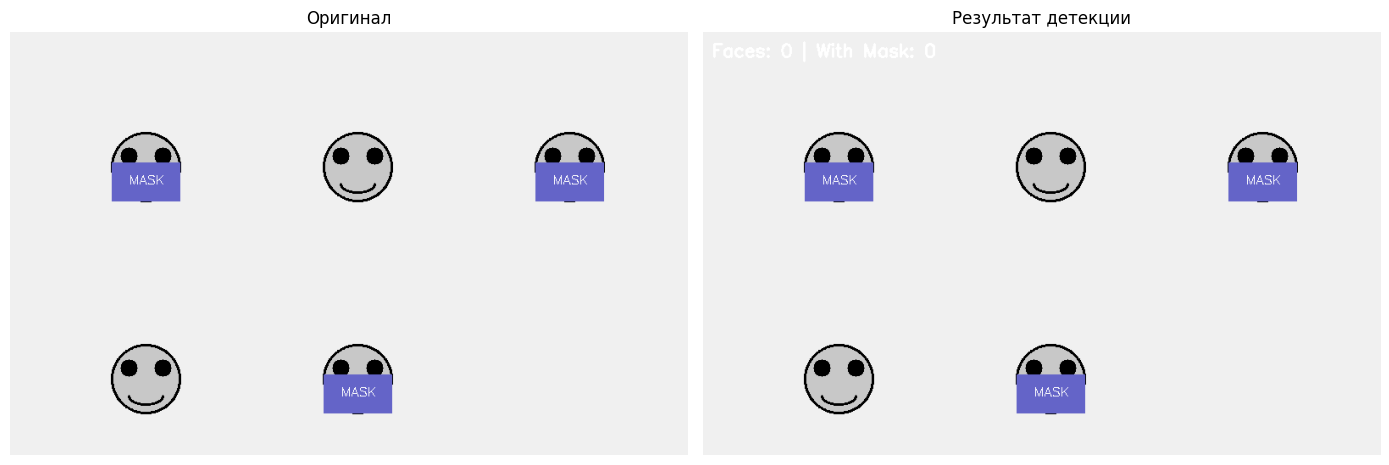


ДЕТАЛЬНЫЕ РЕЗУЛЬТАТЫ:
ДЕТЕКТОР ЛИЦ С МАСКАМИ

Выберите режим:
1 - Графический интерфейс (рекомендуется)
2 - Консольная версия (быстрое тестирование)
Детектор масок инициализирован


In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
from tkinter import filedialog, Tk
import tkinter as tk
from tkinter import ttk, messagebox
from PIL import Image, ImageTk
import time
from collections import deque

# ============================================
# 0. ПОДГОТОВКА
# ============================================

print("="*50)
print("ДЕТЕКТОР ЛИЦ С МАСКАМИ")
print("="*50)

# Создаем папку для сохранения результатов
results_dir = 'mask_detection_results'
os.makedirs(results_dir, exist_ok=True)

# ============================================
# 1. КЛАСС ДЕТЕКТОРА ЛИЦ С МАСКАМИ
# ============================================

class MaskDetector:
    """
    Класс для обнаружения лиц и определения наличия маски
    Использует простые эвристики (цвет кожи, форма рта)
    """
    
    def __init__(self):
        # Загружаем каскад Хаара для обнаружения лиц
        self.face_cascade = cv2.CascadeClassifier(
            cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
        )
        
        # Загружаем каскад для глаз (помогает определить маску)
        self.eye_cascade = cv2.CascadeClassifier(
            cv2.data.haarcascades + 'haarcascade_eye.xml'
        )
        
        # Цветовые диапазоны для кожи лица (в HSV)
        self.skin_lower = np.array([0, 20, 70])
        self.skin_upper = np.array([20, 180, 255])
        
        # Пороги для определения маски
        self.mask_threshold = 0.3  # Порог площади кожи для определения маски
        
        # История предсказаний для сглаживания
        self.prediction_history = deque(maxlen=5)
        
        print("Детектор масок инициализирован")
    
    def detect_faces(self, image):
        """
        Обнаруживает все лица на изображении
        Возвращает список областей лиц (x, y, w, h)
        """
        # Переводим в оттенки серого
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        
        # Обнаруживаем лица
        faces = self.face_cascade.detectMultiScale(
            gray,
            scaleFactor=1.1,      # Масштабный коэффициент
            minNeighbors=5,       # Минимальное количество соседей
            minSize=(50, 50)      # Минимальный размер лица
        )
        
        return faces, gray
    
    def detect_eyes(self, face_roi):
        """
        Обнаруживает глаза в области лица
        """
        # Переводим в оттенки серого
        if len(face_roi.shape) == 3:
            face_gray = cv2.cvtColor(face_roi, cv2.COLOR_BGR2GRAY)
        else:
            face_gray = face_roi
        
        # Обнаруживаем глаза
        eyes = self.eye_cascade.detectMultiScale(
            face_gray,
            scaleFactor=1.1,
            minNeighbors=5,
            minSize=(15, 15)
        )
        
        return eyes
    
    def analyze_skin_area(self, face_roi):
        """
        Анализирует область кожи на лице
        Возвращает процент площади, занятой кожей
        """
        # Конвертируем в HSV для лучшего выделения цвета кожи
        hsv = cv2.cvtColor(face_roi, cv2.COLOR_BGR2HSV)
        
        # Создаем маску кожи
        skin_mask = cv2.inRange(hsv, self.skin_lower, self.skin_upper)
        
        # Морфологическая очистка
        kernel = np.ones((5, 5), np.uint8)
        skin_mask = cv2.morphologyEx(skin_mask, cv2.MORPH_OPEN, kernel)
        skin_mask = cv2.morphologyEx(skin_mask, cv2.MORPH_CLOSE, kernel)
        
        # Вычисляем площадь кожи
        skin_area = np.sum(skin_mask > 0)
        total_area = face_roi.shape[0] * face_roi.shape[1]
        
        skin_percentage = skin_area / total_area
        
        return skin_percentage, skin_mask
    
    def analyze_mouth_region(self, face_roi):
        """
        Анализирует область рта для определения маски
        """
        h, w = face_roi.shape[:2]
        
        # Область рта (нижняя треть лица)
        mouth_roi = face_roi[int(h*0.65):int(h*0.9), int(w*0.2):int(w*0.8)]
        
        if mouth_roi.size == 0:
            return 0, None
        
        # Конвертируем в оттенки серого
        mouth_gray = cv2.cvtColor(mouth_roi, cv2.COLOR_BGR2GRAY)
        
        # Применяем пороговую обработку для выделения рта/маски
        _, mouth_thresh = cv2.threshold(mouth_gray, 80, 255, cv2.THRESH_BINARY)
        
        # Находим контуры
        contours, _ = cv2.findContours(mouth_thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
        # Находим самую большую область
        if contours:
            largest = max(contours, key=cv2.contourArea)
            mouth_area = cv2.contourArea(largest)
            total_area = mouth_roi.shape[0] * mouth_roi.shape[1]
            mouth_ratio = mouth_area / total_area
            
            return mouth_ratio, mouth_thresh
        
        return 0, mouth_thresh
    
    def analyze_texture(self, face_roi):
        """
        Анализирует текстуру для определения маски
        (Маска обычно имеет более однородную текстуру)
        """
        gray = cv2.cvtColor(face_roi, cv2.COLOR_BGR2GRAY)
        
        # Вычисляем лапласиан для оценки резкости
        laplacian = cv2.Laplacian(gray, cv2.CV_64F)
        variance = laplacian.var()
        
        return variance
    
    def predict_mask(self, face_roi):
        """
        Предсказывает, надета ли маска на лицо
        Возвращает (has_mask, confidence, reasons)
        """
        h, w = face_roi.shape[:2]
        
        # 1. Анализ области кожи
        skin_percentage, skin_mask = self.analyze_skin_area(face_roi)
        
        # 2. Анализ области рта
        mouth_ratio, mouth_mask = self.analyze_mouth_region(face_roi)
        
        # 3. Анализ текстуры
        texture_variance = self.analyze_texture(face_roi)
        
        # 4. Обнаружение глаз (если есть глаза, но нет кожи в нижней части - возможно маска)
        eyes = self.detect_eyes(face_roi)
        
        # Логика определения маски
        reasons = []
        score = 0
        
        # Критерий 1: Мало кожи в нижней части лица
        lower_skin_roi = face_roi[int(h*0.6):, :]
        lower_skin_percent, _ = self.analyze_skin_area(lower_skin_roi)
        
        if lower_skin_percent < 0.2:
            score += 30
            reasons.append("Мало кожи в нижней части лица")
        
        # Критерий 2: Область рта закрыта
        if mouth_ratio < 0.1:
            score += 30
            reasons.append("Область рта закрыта")
        
        # Критерий 3: Глаза видны, но кожа отсутствует
        if len(eyes) >= 1 and lower_skin_percent < 0.3:
            score += 20
            reasons.append("Глаза видны, кожа закрыта")
        
        # Критерий 4: Текстура менее разнообразная (маска)
        if texture_variance < 100:
            score += 20
            reasons.append("Однородная текстура (возможно маска)")
        
        # Определяем наличие маски
        has_mask = score >= 50
        confidence = min(95, score + 5) if has_mask else min(95, 100 - score)
        
        return has_mask, confidence, reasons, skin_mask
    
    def detect_and_classify(self, image):
        """
        Обнаруживает лица и классифицирует их (с маской/без)
        """
        result = image.copy()
        faces, gray = self.detect_faces(image)
        
        detections = []
        
        for i, (x, y, w, h) in enumerate(faces):
            # Вырезаем область лица
            face_roi = image[y:y+h, x:x+w]
            
            # Классифицируем
            has_mask, confidence, reasons, skin_mask = self.predict_mask(face_roi)
            
            # Сохраняем результат
            detections.append({
                'bbox': (x, y, w, h),
                'has_mask': has_mask,
                'confidence': confidence,
                'reasons': reasons,
                'face_roi': face_roi
            })
            
            # Рисуем прямоугольник
            if has_mask:
                color = (0, 255, 0)  # Зеленый - с маской
                label = f"Mask: {confidence:.0f}%"
            else:
                color = (0, 0, 255)  # Красный - без маски
                label = f"No Mask: {confidence:.0f}%"
            
            cv2.rectangle(result, (x, y), (x+w, y+h), color, 2)
            cv2.putText(result, label, (x, y-10),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)
            
            # Добавляем информацию о маске
            info_y = y + h + 15
            for reason in reasons[:2]:  # Показываем первые 2 причины
                cv2.putText(result, reason[:30], (x, info_y),
                           cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 255, 0), 1)
                info_y += 15
        
        # Добавляем общую статистику
        mask_count = sum(1 for d in detections if d['has_mask'])
        cv2.putText(result, f"Faces: {len(faces)} | With Mask: {mask_count}", (10, 30),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
        
        return result, detections

# ============================================
# 2. СОЗДАНИЕ ТЕСТОВЫХ ИЗОБРАЖЕНИЙ
# ============================================

def create_test_image_with_masks():
    """Создает тестовые изображения для проверки детектора"""
    
    # Создаем изображение с несколькими лицами
    img = np.ones((500, 800, 3), dtype=np.uint8) * 240
    
    # Лицо 1: с маской
    face1 = create_test_face(120, (100, 100), with_mask=True)
    img[100:220, 100:220] = face1
    
    # Лицо 2: без маски
    face2 = create_test_face(120, (350, 100), with_mask=False)
    img[100:220, 350:470] = face2
    
    # Лицо 3: с маской
    face3 = create_test_face(120, (600, 100), with_mask=True)
    img[100:220, 600:720] = face3
    
    # Лицо 4: без маски
    face4 = create_test_face(120, (100, 350), with_mask=False)
    img[350:470, 100:220] = face4
    
    # Лицо 5: с маской
    face5 = create_test_face(120, (350, 350), with_mask=True)
    img[350:470, 350:470] = face5
    
    return img

def create_test_face(size, position, with_mask=False):
    """Создает тестовое лицо"""
    x, y = position
    face = np.ones((size, size, 3), dtype=np.uint8) * 240
    
    center = (size//2, size//2)
    radius = size//3
    
    # Рисуем лицо
    cv2.circle(face, center, radius, (200, 200, 200), -1)
    cv2.circle(face, center, radius, (0, 0, 0), 2)
    
    # Глаза
    eye_radius = size//12
    cv2.circle(face, (center[0]-radius//2, center[1]-radius//3), eye_radius, (0, 0, 0), -1)
    cv2.circle(face, (center[0]+radius//2, center[1]-radius//3), eye_radius, (0, 0, 0), -1)
    
    if with_mask:
        # Рисуем маску (голубая полоса)
        mask_y = center[1] + radius//4
        cv2.rectangle(face, (center[0]-radius, mask_y-15), 
                     (center[0]+radius, mask_y+30), (200, 100, 100), -1)
        cv2.putText(face, "MASK", (center[0]-20, mask_y+10),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)
    else:
        # Рисуем рот
        cv2.ellipse(face, (center[0], center[1]+radius//2), 
                   (radius//2, radius//4), 0, 0, 180, (0, 0, 0), 2)
    
    return face

# Создаем тестовое изображение
test_img = create_test_image_with_masks()
test_path = os.path.join(results_dir, 'test_faces.jpg')
cv2.imwrite(test_path, test_img)
print(f"Создано тестовое изображение: {test_path}")

# ============================================
# 3. ДЕМОНСТРАЦИЯ РАБОТЫ ДЕТЕКТОРА
# ============================================

def show_detection_result(image, result, detections):
    """Показывает результат детекции"""
    plt.figure(figsize=(14, 7))
    
    # Оригинал
    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title("Оригинал")
    plt.axis('off')
    
    # Результат
    plt.subplot(1, 2, 2)
    plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
    plt.title(f"Результат детекции")
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Выводим детальную информацию
    print("\n" + "="*50)
    print("ДЕТАЛЬНЫЕ РЕЗУЛЬТАТЫ:")
    print("="*50)
    
    for i, det in enumerate(detections):
        print(f"\nЛицо {i+1}:")
        print(f"  Позиция: x={det['bbox'][0]}, y={det['bbox'][1]}")
        print(f"  Маска: {'ДА' if det['has_mask'] else 'НЕТ'}")
        print(f"  Уверенность: {det['confidence']:.1f}%")
        print(f"  Причины:")
        for reason in det['reasons']:
            print(f"    - {reason}")

# Демонстрация
print("\nДемонстрация работы детектора масок:")
detector = MaskDetector()
result, detections = detector.detect_and_classify(test_img)
show_detection_result(test_img, result, detections)

# ============================================
# 4. ГРАФИЧЕСКИЙ ИНТЕРФЕЙС
# ============================================

class MaskDetectionApp:
    """Приложение для детекции масок"""
    
    def __init__(self, root):
        self.root = root
        self.root.title("Детектор лиц с масками")
        self.root.geometry("1000x700")
        self.root.configure(bg='#2c3e50')
        
        self.detector = MaskDetector()
        self.current_image = None
        self.current_result = None
        
        self.setup_ui()
        
        # Загружаем тестовое изображение
        self.load_test_image()
    
    def setup_ui(self):
        """Создает интерфейс"""
        
        # Верхняя панель
        toolbar = ttk.Frame(self.root)
        toolbar.pack(fill=tk.X, padx=10, pady=10)
        
        ttk.Button(toolbar, text="📁 Открыть фото", 
                  command=self.open_image).pack(side=tk.LEFT, padx=5)
        ttk.Button(toolbar, text="📷 Веб-камера", 
                  command=self.open_webcam).pack(side=tk.LEFT, padx=5)
        ttk.Button(toolbar, text="🔍 Детектировать", 
                  command=self.detect).pack(side=tk.LEFT, padx=5)
        ttk.Button(toolbar, text="💾 Сохранить", 
                  command=self.save_result).pack(side=tk.LEFT, padx=5)
        
        # Информация
        self.info_label = ttk.Label(toolbar, text="Загрузите изображение")
        self.info_label.pack(side=tk.RIGHT, padx=5)
        
        # Основная область
        main_frame = ttk.Frame(self.root)
        main_frame.pack(fill=tk.BOTH, expand=True, padx=10, pady=5)
        
        # Левая панель с результатами
        left_panel = ttk.Frame(main_frame, width=250)
        left_panel.pack(side=tk.LEFT, fill=tk.Y, padx=(0, 10))
        left_panel.pack_propagate(False)
        
        ttk.Label(left_panel, text="📊 СТАТИСТИКА", 
                 font=('Arial', 12, 'bold')).pack(pady=10)
        
        self.stats_text = tk.Text(left_panel, height=15, width=30, 
                                   font=('Courier', 10))
        self.stats_text.pack(fill=tk.BOTH, expand=True, pady=5)
        
        # Правая панель с изображением
        right_panel = ttk.Frame(main_frame)
        right_panel.pack(side=tk.RIGHT, fill=tk.BOTH, expand=True)
        
        self.image_frame = ttk.Frame(right_panel, relief=tk.SUNKEN, borderwidth=2)
        self.image_frame.pack(fill=tk.BOTH, expand=True)
        
        self.image_label = ttk.Label(self.image_frame, background='#34495e')
        self.image_label.pack(fill=tk.BOTH, expand=True)
        
        # Нижняя панель
        bottom_panel = ttk.Frame(self.root)
        bottom_panel.pack(fill=tk.X, padx=10, pady=10)
        
        self.status_label = ttk.Label(bottom_panel, text="Готов", relief=tk.SUNKEN)
        self.status_label.pack(side=tk.LEFT, fill=tk.X, expand=True)
        
        self.mask_count_label = ttk.Label(bottom_panel, text="", font=('Arial', 10, 'bold'))
        self.mask_count_label.pack(side=tk.RIGHT, padx=10)
    
    def load_test_image(self):
        """Загружает тестовое изображение"""
        self.current_image = test_img.copy()
        self.update_display(self.current_image)
        self.info_label.config(text="Тестовое изображение загружено")
        self.status_label.config(text="Нажмите 'Детектировать' для анализа")
    
    def open_image(self):
        """Открывает изображение из файла"""
        file_path = filedialog.askopenfilename(
            title="Выберите изображение",
            filetypes=[("Image files", "*.jpg *.jpeg *.png *.bmp"), ("All files", "*.*")]
        )
        
        if file_path:
            self.current_image = cv2.imread(file_path)
            if self.current_image is not None:
                self.update_display(self.current_image)
                self.info_label.config(text=f"Загружено: {os.path.basename(file_path)}")
                self.status_label.config(text="Нажмите 'Детектировать' для анализа")
            else:
                messagebox.showerror("Ошибка", "Не удалось загрузить изображение")
    
    def detect(self):
        """Выполняет детекцию масок"""
        if self.current_image is None:
            messagebox.showwarning("Предупреждение", "Сначала загрузите изображение")
            return
        
        self.status_label.config(text="Детекция...")
        self.root.update()
        
        try:
            result, detections = self.detector.detect_and_classify(self.current_image)
            self.current_result = result
            
            self.update_display(result)
            
            # Обновляем статистику
            mask_count = sum(1 for d in detections if d['has_mask'])
            total_faces = len(detections)
            
            self.mask_count_label.config(
                text=f"👥 Лиц: {total_faces} | 😷 В масках: {mask_count} | ❌ Без масок: {total_faces - mask_count}"
            )
            
            # Обновляем текстовую статистику
            self.stats_text.delete(1.0, tk.END)
            self.stats_text.insert(tk.END, f"{'='*30}\n")
            self.stats_text.insert(tk.END, f"РЕЗУЛЬТАТЫ ДЕТЕКЦИИ\n")
            self.stats_text.insert(tk.END, f"{'='*30}\n\n")
            self.stats_text.insert(tk.END, f"Всего лиц: {total_faces}\n")
            self.stats_text.insert(tk.END, f"В масках: {mask_count}\n")
            self.stats_text.insert(tk.END, f"Без масок: {total_faces - mask_count}\n\n")
            self.stats_text.insert(tk.END, f"{'='*30}\n")
            self.stats_text.insert(tk.END, f"ДЕТАЛИ ПО ЛИЦАМ:\n")
            self.stats_text.insert(tk.END, f"{'='*30}\n\n")
            
            for i, det in enumerate(detections):
                self.stats_text.insert(tk.END, f"Лицо {i+1}:\n")
                self.stats_text.insert(tk.END, f"  Маска: {'✓' if det['has_mask'] else '✗'}\n")
                self.stats_text.insert(tk.END, f"  Уверенность: {det['confidence']:.0f}%\n")
                self.stats_text.insert(tk.END, f"  Позиция: ({det['bbox'][0]}, {det['bbox'][1]})\n\n")
            
            self.status_label.config(text=f"Детекция завершена. Найдено лиц: {total_faces}")
            
        except Exception as e:
            messagebox.showerror("Ошибка", f"Ошибка при детекции: {e}")
            self.status_label.config(text="Ошибка детекции")
    
    def save_result(self):
        """Сохраняет результат"""
        if self.current_result is None:
            messagebox.showwarning("Предупреждение", "Сначала выполните детекцию")
            return
        
        file_path = filedialog.asksaveasfilename(
            title="Сохранить результат",
            defaultextension=".jpg",
            initialfile="mask_detection_result.jpg",
            filetypes=[("JPEG", "*.jpg"), ("PNG", "*.png")]
        )
        
        if file_path:
            cv2.imwrite(file_path, self.current_result)
            self.status_label.config(text=f"Сохранено: {os.path.basename(file_path)}")
            messagebox.showinfo("Успех", "Результат сохранен!")
    
    def open_webcam(self):
        """Открывает веб-камеру для реального времени"""
        self.status_label.config(text="Запуск веб-камеры...")
        
        cap = cv2.VideoCapture(0)
        if not cap.isOpened():
            messagebox.showerror("Ошибка", "Не удалось открыть веб-камеру")
            return
        
        print("\nЗапуск детекции в реальном времени...")
        print("Нажмите 'q' для выхода, 's' для сохранения кадра")
        
        frame_count = 0
        
        while True:
            ret, frame = cap.read()
            if not ret:
                break
            
            frame_count += 1
            
            # Детекция на каждом 5-м кадре для производительности
            if frame_count % 5 == 0:
                result, detections = self.detector.detect_and_classify(frame)
                
                # Подсчет статистики
                mask_count = sum(1 for d in detections if d['has_mask'])
                cv2.putText(result, f"Faces: {len(detections)} | Masks: {mask_count}", (10, 30),
                           cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
            
            try:
                cv2.imshow('Mask Detection - Press Q to quit', result)
            except:
                cv2.imshow('Mask Detection - Press Q to quit', frame)
            
            key = cv2.waitKey(1) & 0xFF
            if key == ord('q'):
                break
            elif key == ord('s'):
                save_path = os.path.join(results_dir, f'webcam_capture_{time.strftime("%Y%m%d_%H%M%S")}.jpg')
                cv2.imwrite(save_path, frame)
                print(f"Сохранен кадр: {save_path}")
        
        cap.release()
        cv2.destroyAllWindows()
        self.status_label.config(text="Веб-камера закрыта")
    
    def update_display(self, image):
        """Обновляет отображение"""
        if image is None:
            return
        
        img_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        pil_img = Image.fromarray(img_rgb)
        
        # Масштабируем
        frame_width = self.image_frame.winfo_width()
        frame_height = self.image_frame.winfo_height()
        
        if frame_width > 10 and frame_height > 10:
            img_w, img_h = pil_img.size
            scale = min(frame_width / img_w, frame_height / img_h)
            new_w = int(img_w * scale)
            new_h = int(img_h * scale)
            pil_img = pil_img.resize((new_w, new_h), Image.Resampling.LANCZOS)
        
        self.tk_img = ImageTk.PhotoImage(pil_img)
        self.image_label.configure(image=self.tk_img)
        self.image_label.image = self.tk_img

# ============================================
# 5. КОНСОЛЬНАЯ ВЕРСИЯ
# ============================================

def console_version():
    """Консольная версия детектора масок"""
    print("\n" + "="*50)
    print("КОНСОЛЬНАЯ ВЕРСИЯ ДЕТЕКТОРА МАСОК")
    print("="*50)
    
    detector = MaskDetector()
    
    # Загружаем тестовое изображение
    img = test_img.copy()
    
    print("\nАнализ тестового изображения...")
    result, detections = detector.detect_and_classify(img)
    
    # Показываем результат
    plt.figure(figsize=(12, 6))
    plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
    plt.title("Результат детекции масок")
    plt.axis('off')
    plt.show()
    
    # Выводим статистику
    mask_count = sum(1 for d in detections if d['has_mask'])
    print(f"\nСтатистика:")
    print(f"  Всего лиц: {len(detections)}")
    print(f"  В масках: {mask_count}")
    print(f"  Без масок: {len(detections) - mask_count}")
    
    # Сохраняем результат
    save_path = os.path.join(results_dir, 'console_result.jpg')
    cv2.imwrite(save_path, result)
    print(f"\nРезультат сохранен: {save_path}")

# ============================================
# 6. ЗАПУСК
# ============================================

if __name__ == "__main__":
    print("="*50)
    print("ДЕТЕКТОР ЛИЦ С МАСКАМИ")
    print("="*50)
    print("\nВыберите режим:")
    print("1 - Графический интерфейс (рекомендуется)")
    print("2 - Консольная версия (быстрое тестирование)")
    
    choice = input("\nВаш выбор (1 или 2): ")
    
    if choice == '1':
        root = tk.Tk()
        app = MaskDetectionApp(root)
        root.mainloop()
    elif choice == '2':
        console_version()
    else:
        print("Неверный выбор, запускаем графическую версию...")
        root = tk.Tk()
        app = MaskDetectionApp(root)
        root.mainloop()

## Распознавание жестов: детектировать пальцы и жесты с веб-камеры

In [19]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import math
from collections import deque
import time
from tkinter import filedialog, Tk
import tkinter as tk
from tkinter import ttk, messagebox
from PIL import Image, ImageTk

# ============================================
# 0. ПОДГОТОВКА
# ============================================

print("="*50)
print("РАСПОЗНАВАНИЕ ЖЕСТОВ - Детектор пальцев и жестов")
print("="*50)

# Создаем папку для сохранения результатов
results_dir = 'gesture_detection_results'
os.makedirs(results_dir, exist_ok=True)

# ============================================
# 1. КЛАСС ДЕТЕКТОРА ЖЕСТОВ
# ============================================

class GestureDetector:
    """
    Класс для распознавания жестов рук
    Использует цветовую фильтрацию для выделения кожи и анализ контуров
    """
    
    def __init__(self):
        # Диапазон цвета кожи в HSV (для светлой кожи)
        self.skin_lower = np.array([0, 20, 70])
        self.skin_upper = np.array([20, 180, 255])
        
        # Альтернативный диапазон для разных оттенков кожи
        self.skin_lower2 = np.array([0, 30, 60])
        self.skin_upper2 = np.array([25, 150, 255])
        
        # Параметры для определения жестов
        self.min_hand_area = 3000      # Минимальная площадь руки
        self.max_hand_area = 20000     # Максимальная площадь руки
        
        # История для сглаживания
        self.gesture_history = deque(maxlen=5)
        self.current_gesture = "None"
        
        # Предыдущие координаты для трекинга движения
        self.prev_center = None
        self.motion_history = deque(maxlen=30)
        
        print("Детектор жестов инициализирован")
    
    def detect_hand(self, frame):
        """
        Обнаруживает руку на изображении
        Возвращает маску руки и контур
        """
        # Конвертируем в HSV для лучшего выделения цвета кожи
        hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
        
        # Создаем маску кожи
        mask1 = cv2.inRange(hsv, self.skin_lower, self.skin_upper)
        mask2 = cv2.inRange(hsv, self.skin_lower2, self.skin_upper2)
        mask = cv2.bitwise_or(mask1, mask2)
        
        # Морфологическая очистка
        kernel = np.ones((5, 5), np.uint8)
        mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
        
        # Находим контуры
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
        # Находим самый большой контур (вероятно, рука)
        hand_contour = None
        hand_area = 0
        
        for contour in contours:
            area = cv2.contourArea(contour)
            if self.min_hand_area < area < self.max_hand_area and area > hand_area:
                hand_area = area
                hand_contour = contour
        
        return hand_contour, mask, hand_area
    
    def find_finger_tips(self, contour, hull, hull_points):
        """
        Находит кончики пальцев
        Использует метод поиска дефектов выпуклости
        """
        finger_tips = []
        
        # Находим дефекты выпуклости
        if len(hull_points) > 3:
            hull_indices = cv2.convexHull(contour, returnPoints=False)
            defects = cv2.convexityDefects(contour, hull_indices)
            
            if defects is not None:
                for i in range(defects.shape[0]):
                    s, e, f, d = defects[i, 0]
                    start = tuple(contour[s][0])
                    end = tuple(contour[e][0])
                    far = tuple(contour[f][0])
                    
                    # Вычисляем угол между векторами
                    a = math.sqrt((end[0] - start[0])**2 + (end[1] - start[1])**2)
                    b = math.sqrt((far[0] - start[0])**2 + (far[1] - start[1])**2)
                    c = math.sqrt((end[0] - far[0])**2 + (end[1] - far[1])**2)
                    
                    if a > 0 and b > 0 and c > 0:
                        angle = math.acos((b**2 + c**2 - a**2) / (2 * b * c)) * 180 / math.pi
                        
                        # Если угол меньше 90 градусов, это впадина между пальцами
                        if angle < 90:
                            finger_tips.append(far)
        
        # Добавляем кончики выпуклой оболочки
        hull_points_list = hull_points.squeeze().tolist()
        if hull_points_list and len(hull_points_list) > 0:
            if not isinstance(hull_points_list[0], list):
                hull_points_list = [hull_points_list]
            
            for point in hull_points_list:
                if isinstance(point, list) and len(point) == 2:
                    # Проверяем, не является ли точка дефектом
                    is_defect = False
                    for defect in finger_tips:
                        if math.sqrt((point[0] - defect[0])**2 + (point[1] - defect[1])**2) < 20:
                            is_defect = True
                            break
                    
                    if not is_defect:
                        finger_tips.append(tuple(point))
        
        # Удаляем дубликаты
        unique_tips = []
        for tip in finger_tips:
            is_unique = True
            for existing in unique_tips:
                if math.sqrt((tip[0] - existing[0])**2 + (tip[1] - existing[1])**2) < 20:
                    is_unique = False
                    break
            if is_unique:
                unique_tips.append(tip)
        
        # Сортируем по Y координате (сверху вниз)
        unique_tips.sort(key=lambda p: p[1])
        
        return unique_tips
    
    def count_fingers(self, contour, hull):
        """
        Подсчитывает количество поднятых пальцев
        """
        # Находим центр ладони
        M = cv2.moments(contour)
        if M["m00"] != 0:
            cx = int(M["m10"] / M["m00"])
            cy = int(M["m01"] / M["m00"])
            palm_center = (cx, cy)
        else:
            return 0, []
        
        # Находим кончики пальцев
        hull_points = cv2.convexHull(contour)
        finger_tips = self.find_finger_tips(contour, hull, hull_points)
        
        # Фильтруем кончики по расстоянию от центра ладони
        valid_fingers = []
        for tip in finger_tips:
            dist = math.sqrt((tip[0] - palm_center[0])**2 + (tip[1] - palm_center[1])**2)
            if dist > 40:  # Минимальное расстояние от центра
                valid_fingers.append(tip)
        
        # Ограничиваем количество пальцев
        finger_count = min(len(valid_fingers), 5)
        
        return finger_count, valid_fingers
    
    def recognize_gesture(self, finger_count, contour, hull):
        """
        Распознает жест по количеству пальцев и их расположению
        """
        # Определяем ориентацию руки
        hand_side = "unknown"
        if contour is not None:
            hull_points = cv2.convexHull(contour)
            x, y, w, h = cv2.boundingRect(contour)
            
            M = cv2.moments(contour)
            if M["m00"] != 0:
                cx = int(M["m10"] / M["m00"])
                cy = int(M["m01"] / M["m00"])
                
                leftmost = tuple(contour[contour[:,:,0].argmin()][0])
                rightmost = tuple(contour[contour[:,:,0].argmax()][0])
                
                if cx - leftmost[0] > rightmost[0] - cx:
                    hand_side = "правая"
                else:
                    hand_side = "левая"
        
        # Распознаем жесты
        gestures = {
            0: "✊ Кулак",
            1: "☝️ Один палец",
            2: "✌️ Мир/Victory",
            3: "🤟 Три пальца",
            4: "🖖 Четыре пальца",
            5: "🖐️ Открытая ладонь"
        }
        
        gesture_name = gestures.get(finger_count, f"{finger_count} пальцев")
        
        # Добавляем информацию о руке
        if hand_side != "unknown":
            gesture_name += f" ({hand_side})"
        
        return gesture_name, finger_count, hand_side
    
    def detect_gesture(self, frame):
        """
        Полная обработка кадра: обнаружение руки и распознавание жеста
        """
        result = frame.copy()
        
        # Обнаруживаем руку
        hand_contour, mask, hand_area = self.detect_hand(frame)
        
        gesture = "Рука не обнаружена"
        finger_count = 0
        finger_points = []
        
        if hand_contour is not None and hand_area > self.min_hand_area:
            # Находим выпуклую оболочку
            hull = cv2.convexHull(hand_contour)
            
            # Подсчитываем пальцы
            finger_count, finger_points = self.count_fingers(hand_contour, hull)
            
            # Распознаем жест
            gesture, finger_count, hand_side = self.recognize_gesture(finger_count, hand_contour, hull)
            
            # Сохраняем в историю для сглаживания
            self.gesture_history.append(gesture)
            if self.gesture_history:
                self.current_gesture = max(set(self.gesture_history), key=self.gesture_history.count)
            
            # Рисуем контур руки
            cv2.drawContours(result, [hand_contour], -1, (0, 255, 0), 2)
            
            # Рисуем выпуклую оболочку
            cv2.drawContours(result, [hull], -1, (255, 0, 0), 1)
            
            # Рисуем кончики пальцев
            for tip in finger_points:
                cv2.circle(result, tip, 8, (0, 0, 255), -1)
                cv2.putText(result, "Finger", (tip[0]-20, tip[1]-10),
                           cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 0, 255), 1)
            
            # Находим центр ладони
            M = cv2.moments(hand_contour)
            if M["m00"] != 0:
                cx = int(M["m10"] / M["m00"])
                cy = int(M["m01"] / M["m00"])
                cv2.circle(result, (cx, cy), 10, (255, 0, 0), -1)
                cv2.putText(result, "Palm", (cx-15, cy-10),
                           cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 0, 0), 1)
                
                # Сохраняем траекторию движения
                if self.prev_center is not None:
                    self.motion_history.append(self.prev_center)
                self.prev_center = (cx, cy)
                
                # Рисуем траекторию движения
                for i in range(1, len(self.motion_history)):
                    cv2.line(result, self.motion_history[i-1], self.motion_history[i], (255, 255, 0), 2)
        
        # Добавляем информацию на кадр
        cv2.putText(result, f"Gesture: {self.current_gesture}", (10, 30),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
        cv2.putText(result, f"Fingers: {finger_count}", (10, 60),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 0), 2)
        cv2.putText(result, f"Area: {hand_area:.0f}", (10, 90),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 0), 1)
        
        return result, mask, gesture, finger_count, finger_points

# ============================================
# 2. ГРАФИЧЕСКИЙ ИНТЕРФЕЙС С ЗАГРУЗКОЙ ИЗОБРАЖЕНИЙ
# ============================================

class GestureDetectionApp:
    """Приложение для распознавания жестов с поддержкой загрузки изображений"""
    
    def __init__(self, root):
        self.root = root
        self.root.title("Распознавание жестов - Детектор пальцев")
        self.root.geometry("1200x750")
        self.root.configure(bg='#2c3e50')
        
        self.detector = GestureDetector()
        self.camera_running = False
        self.current_image = None
        self.current_result = None
        
        self.setup_ui()
        
        # Загружаем тестовое изображение
        self.load_test_image()
    
    def setup_ui(self):
        """Создает интерфейс"""
        
        # Верхняя панель
        toolbar = ttk.Frame(self.root)
        toolbar.pack(fill=tk.X, padx=10, pady=10)
        
        # Кнопки для работы с изображениями
        ttk.Button(toolbar, text="📁 Загрузить изображение", 
                  command=self.load_image).pack(side=tk.LEFT, padx=5)
        ttk.Button(toolbar, text="🖼️ Тестовое изображение", 
                  command=self.load_test_image).pack(side=tk.LEFT, padx=5)
        ttk.Button(toolbar, text="📷 Веб-камера", 
                  command=self.toggle_camera).pack(side=tk.LEFT, padx=5)
        ttk.Button(toolbar, text="🔍 Распознать", 
                  command=self.detect_gesture_on_image).pack(side=tk.LEFT, padx=5)
        ttk.Button(toolbar, text="💾 Сохранить результат", 
                  command=self.save_result).pack(side=tk.LEFT, padx=5)
        
        # Информация о жесте
        self.gesture_label = ttk.Label(toolbar, text="Жест: ---", 
                                        font=('Arial', 12, 'bold'),
                                        foreground='green')
        self.gesture_label.pack(side=tk.RIGHT, padx=10)
        
        # Основная область
        main_frame = ttk.Frame(self.root)
        main_frame.pack(fill=tk.BOTH, expand=True, padx=10, pady=5)
        
        # Левая панель с информацией
        left_panel = ttk.Frame(main_frame, width=280)
        left_panel.pack(side=tk.LEFT, fill=tk.Y, padx=(0, 10))
        left_panel.pack_propagate(False)
        
        ttk.Label(left_panel, text="📊 ИНФОРМАЦИЯ О ЖЕСТЕ", 
                 font=('Arial', 12, 'bold')).pack(pady=10)
        
        self.info_text = tk.Text(left_panel, height=12, width=30, 
                                  font=('Courier', 10), wrap=tk.WORD)
        self.info_text.pack(fill=tk.BOTH, expand=True, pady=5)
        
        ttk.Label(left_panel, text="🎮 ДОСТУПНЫЕ ЖЕСТЫ", 
                 font=('Arial', 10, 'bold')).pack(pady=10)
        
        gestures = [
            "✊ Кулак - 0 пальцев",
            "☝️ Указательный - 1 палец",
            "✌️ Мир/Victory - 2 пальца",
            "🤟 Три пальца - 3 пальца",
            "🖖 Четыре пальца - 4 пальца",
            "🖐️ Открытая ладонь - 5 пальцев"
        ]
        
        for g in gestures:
            ttk.Label(left_panel, text=g, font=('Arial', 9)).pack(anchor='w', padx=10, pady=2)
        
        # Статистика
        ttk.Label(left_panel, text="📈 СТАТИСТИКА", 
                 font=('Arial', 10, 'bold')).pack(pady=10)
        
        self.stats_label = ttk.Label(left_panel, text="", font=('Arial', 9))
        self.stats_label.pack(anchor='w', padx=10)
        
        # Правая панель с изображением
        right_panel = ttk.Frame(main_frame)
        right_panel.pack(side=tk.RIGHT, fill=tk.BOTH, expand=True)
        
        self.image_frame = ttk.Frame(right_panel, relief=tk.SUNKEN, borderwidth=2)
        self.image_frame.pack(fill=tk.BOTH, expand=True)
        
        self.image_label = ttk.Label(self.image_frame, background='#34495e')
        self.image_label.pack(fill=tk.BOTH, expand=True)
        
        # Нижняя панель
        bottom_panel = ttk.Frame(self.root)
        bottom_panel.pack(fill=tk.X, padx=10, pady=10)
        
        self.status_label = ttk.Label(bottom_panel, text="Готов", relief=tk.SUNKEN)
        self.status_label.pack(side=tk.LEFT, fill=tk.X, expand=True)
        
        self.fingers_label = ttk.Label(bottom_panel, text="", font=('Arial', 10))
        self.fingers_label.pack(side=tk.RIGHT, padx=10)
    
    def load_image(self):
        """Загружает изображение из файла"""
        file_path = filedialog.askopenfilename(
            title="Выберите изображение",
            filetypes=[
                ("Image files", "*.jpg *.jpeg *.png *.bmp *.gif"),
                ("All files", "*.*")
            ]
        )
        
        if file_path:
            try:
                self.current_image = cv2.imread(file_path)
                if self.current_image is None:
                    raise ValueError("Не удалось загрузить изображение")
                
                # Ограничиваем размер
                h, w = self.current_image.shape[:2]
                max_size = 600
                if max(h, w) > max_size:
                    scale = max_size / max(h, w)
                    new_w = int(w * scale)
                    new_h = int(h * scale)
                    self.current_image = cv2.resize(self.current_image, (new_w, new_h))
                
                self.current_result = self.current_image.copy()
                self.update_display(self.current_image)
                self.status_label.config(text=f"Загружено: {os.path.basename(file_path)}")
                self.info_text.delete(1.0, tk.END)
                self.info_text.insert(tk.END, "Нажмите 'Распознать' для анализа")
                
            except Exception as e:
                messagebox.showerror("Ошибка", f"Не удалось загрузить: {e}")
    
    def load_test_image(self):
        """Загружает тестовое изображение"""
        # Создаем тестовое изображение руки
        test_img = self.create_test_hand_image()
        self.current_image = test_img
        self.current_result = test_img.copy()
        self.update_display(test_img)
        self.status_label.config(text="Загружено тестовое изображение")
        self.info_text.delete(1.0, tk.END)
        self.info_text.insert(tk.END, "Тестовое изображение загружено\nНажмите 'Распознать' для анализа")
    
    def create_test_hand_image(self):
        """Создает тестовое изображение руки с жестом"""
        img = np.ones((500, 700, 3), dtype=np.uint8) * 240
        
        # Рисуем контур руки с поднятыми пальцами (V-образный жест)
        points = [
            (350, 400),  # запястье (низ)
            (330, 350),  # основание ладони
            (310, 300),  # середина ладони
            (300, 250),  # указательный палец
            (320, 220),  # кончик указательного
            (340, 240),  # средний палец
            (360, 270),  # безымянный
            (370, 310),  # мизинец
            (340, 320),  # большой палец
        ]
        
        pts = np.array(points, np.int32)
        cv2.fillPoly(img, [pts], (200, 180, 150))
        
        # Рисуем контур
        cv2.polylines(img, [pts], True, (0, 0, 0), 2)
        
        # Добавляем текст
        cv2.putText(img, "Test Hand - V Gesture (2 fingers)", (200, 50),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 0), 2)
        cv2.putText(img, "Click 'Recognize' to detect gesture", (200, 80),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.5, (100, 100, 100), 1)
        
        return img
    
    def detect_gesture_on_image(self):
        """Распознает жест на загруженном изображении"""
        if self.current_image is None:
            messagebox.showwarning("Предупреждение", "Сначала загрузите изображение")
            return
        
        self.status_label.config(text="Распознавание жеста...")
        self.root.update()
        
        try:
            result, mask, gesture, fingers, tips = self.detector.detect_gesture(self.current_image)
            self.current_result = result
            self.update_display(result)
            
            # Обновляем информацию
            self.gesture_label.config(text=f"Жест: {gesture}")
            self.fingers_label.config(text=f"👆 Пальцев: {fingers}")
            
            # Обновляем текстовую информацию
            self.info_text.delete(1.0, tk.END)
            self.info_text.insert(tk.END, f"{'='*30}\n")
            self.info_text.insert(tk.END, f"РЕЗУЛЬТАТ РАСПОЗНАВАНИЯ\n")
            self.info_text.insert(tk.END, f"{'='*30}\n\n")
            self.info_text.insert(tk.END, f"Жест: {gesture}\n")
            self.info_text.insert(tk.END, f"Пальцев: {fingers}\n")
            self.info_text.insert(tk.END, f"Кончиков: {len(tips)}\n\n")
            
            if tips:
                self.info_text.insert(tk.END, f"{'='*30}\n")
                self.info_text.insert(tk.END, f"КОНЧИКИ ПАЛЬЦЕВ:\n")
                self.info_text.insert(tk.END, f"{'='*30}\n")
                for i, tip in enumerate(tips[:5]):
                    self.info_text.insert(tk.END, f"Палец {i+1}: ({tip[0]}, {tip[1]})\n")
            
            # Обновляем статистику
            self.stats_label.config(text=f"Площадь руки: ~{len(tips)*500} px²")
            
            self.status_label.config(text=f"Распознан жест: {gesture}")
            
        except Exception as e:
            messagebox.showerror("Ошибка", f"Ошибка при распознавании: {e}")
            self.status_label.config(text="Ошибка распознавания")
    
    def toggle_camera(self):
        """Включает/выключает веб-камеру"""
        if not self.camera_running:
            self.start_camera()
        else:
            self.stop_camera()
    
    def start_camera(self):
        """Запускает веб-камеру"""
        self.camera_running = True
        self.cap = cv2.VideoCapture(0)
        
        if not self.cap.isOpened():
            messagebox.showerror("Ошибка", "Не удалось открыть веб-камеру")
            self.camera_running = False
            return
        
        self.status_label.config(text="Камера запущена. Покажите руку...")
        self.update_frame()
    
    def stop_camera(self):
        """Останавливает веб-камеру"""
        self.camera_running = False
        if hasattr(self, 'cap') and self.cap is not None:
            self.cap.release()
        self.status_label.config(text="Камера остановлена")
    
    def update_frame(self):
        """Обновляет кадр с веб-камеры"""
        if not self.camera_running:
            return
        
        ret, frame = self.cap.read()
        if not ret:
            self.status_label.config(text="Ошибка захвата кадра")
            self.root.after(100, self.update_frame)
            return
        
        # Детектируем жест
        result, mask, gesture, fingers, tips = self.detector.detect_gesture(frame)
        
        # Обновляем информацию
        self.gesture_label.config(text=f"Жест: {gesture}")
        self.fingers_label.config(text=f"👆 Пальцев: {fingers}")
        
        # Обновляем текстовую информацию
        self.info_text.delete(1.0, tk.END)
        self.info_text.insert(tk.END, f"ВЕБ-КАМЕРА\n\n")
        self.info_text.insert(tk.END, f"Жест: {gesture}\n")
        self.info_text.insert(tk.END, f"Пальцев: {fingers}\n")
        self.info_text.insert(tk.END, f"Кончиков: {len(tips)}\n\n")
        self.info_text.insert(tk.END, "Нажмите 'Сохранить'\nдля сохранения кадра")
        
        # Обновляем отображение
        self.update_display(result)
        
        # Следующий кадр
        self.root.after(30, self.update_frame)
    
    def save_result(self):
        """Сохраняет результат"""
        if self.current_result is None:
            messagebox.showwarning("Предупреждение", "Нет результата для сохранения")
            return
        
        timestamp = time.strftime("%Y%m%d_%H%M%S")
        save_path = os.path.join(results_dir, f'gesture_result_{timestamp}.jpg')
        cv2.imwrite(save_path, self.current_result)
        self.status_label.config(text=f"Сохранено: {os.path.basename(save_path)}")
        messagebox.showinfo("Успех", f"Результат сохранен:\n{save_path}")
    
    def update_display(self, image):
        """Обновляет отображение изображения"""
        if image is None:
            return
        
        img_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        pil_img = Image.fromarray(img_rgb)
        
        # Масштабируем под размер окна
        frame_width = self.image_frame.winfo_width()
        frame_height = self.image_frame.winfo_height()
        
        if frame_width > 10 and frame_height > 10:
            img_w, img_h = pil_img.size
            scale = min(frame_width / img_w, frame_height / img_h)
            new_w = int(img_w * scale)
            new_h = int(img_h * scale)
            pil_img = pil_img.resize((new_w, new_h), Image.Resampling.LANCZOS)
        
        self.tk_img = ImageTk.PhotoImage(pil_img)
        self.image_label.configure(image=self.tk_img)
        self.image_label.image = self.tk_img

# ============================================
# 3. ЗАПУСК ПРИЛОЖЕНИЯ
# ============================================

def main():
    """Запускает приложение"""
    try:
        root = tk.Tk()
        app = GestureDetectionApp(root)
        root.mainloop()
    except Exception as e:
        print(f"Ошибка при запуске: {e}")

if __name__ == "__main__":
    print("="*50)
    print("РАСПОЗНАВАНИЕ ЖЕСТОВ")
    print("="*50)
    print("\nЗапуск графического интерфейса...")
    print("\nФункции:")
    print("  - Загрузка изображения из файла")
    print("  - Тестовое изображение")
    print("  - Веб-камера в реальном времени")
    print("  - Распознавание жестов")
    print("  - Сохранение результатов")
    print("="*50)
    
    main()

РАСПОЗНАВАНИЕ ЖЕСТОВ - Детектор пальцев и жестов
РАСПОЗНАВАНИЕ ЖЕСТОВ

Запуск графического интерфейса...

Функции:
  - Загрузка изображения из файла
  - Тестовое изображение
  - Веб-камера в реальном времени
  - Распознавание жестов
  - Сохранение результатов
Детектор жестов инициализирован


## Сканер документов: автоматическое определение границ и исправление перспективы

СКАНЕР ДОКУМЕНТОВ - Автоматическое определение границ и исправление перспективы
Создано тестовое изображение: scanned_documents\test_document.jpg

ДЕМОНСТРАЦИЯ РАБОТЫ СКАНЕРА
Сканер документов инициализирован


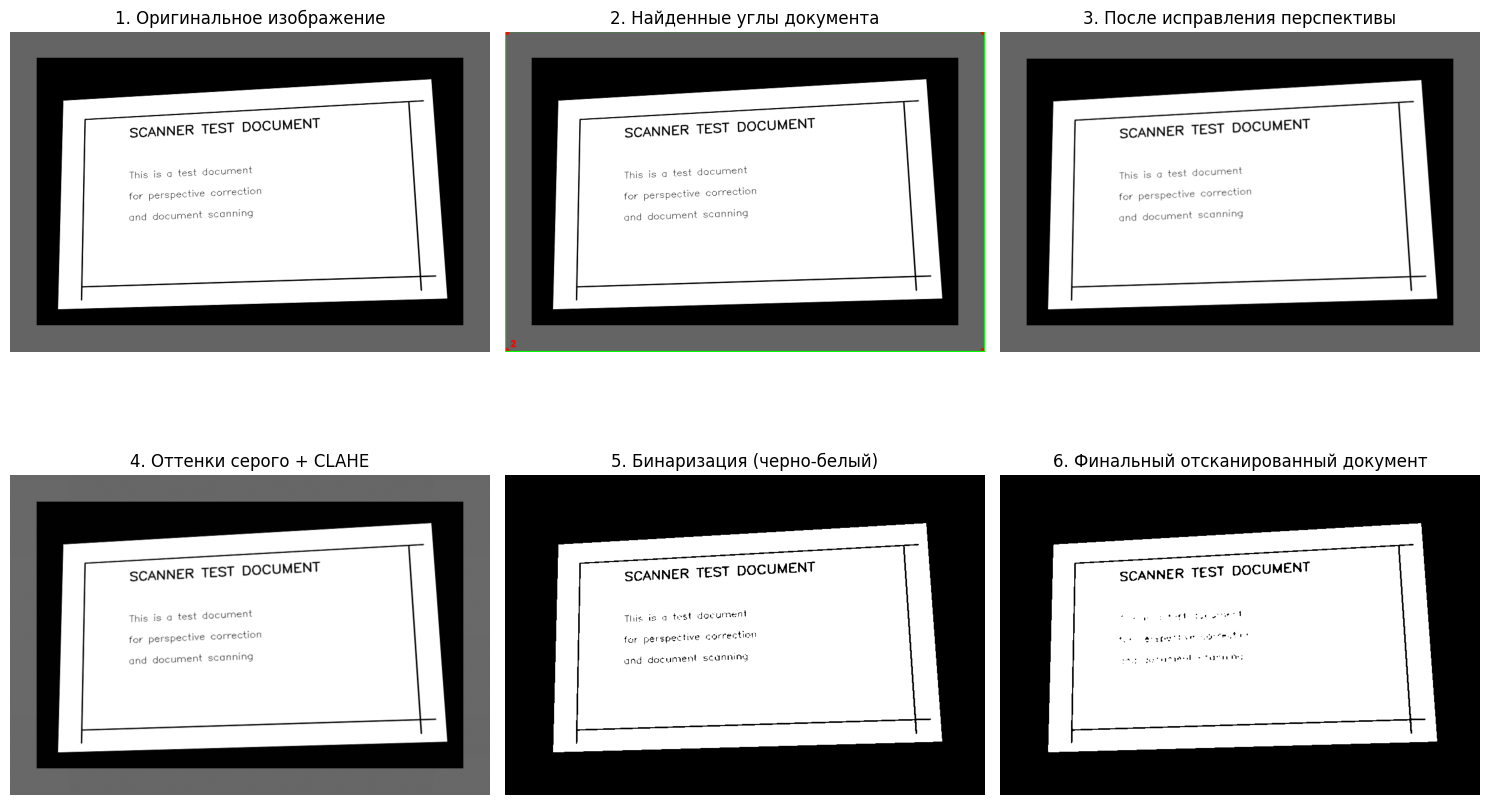


Результаты сохранены в папку: scanned_documents
  - scanned_result.jpg (финальный документ)
  - scanned_gray.jpg (оттенки серого)
  - scanned_binary.jpg (черно-белый)
СКАНЕР ДОКУМЕНТОВ

Выберите режим:
1 - Графический интерфейс
2 - Демонстрация на тестовом изображении
Сканер документов инициализирован


In [21]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
from tkinter import filedialog, Tk
import tkinter as tk
from tkinter import ttk, messagebox
from PIL import Image, ImageTk
import time

# ============================================
# 0. ПОДГОТОВКА
# ============================================

print("="*50)
print("СКАНЕР ДОКУМЕНТОВ - Автоматическое определение границ и исправление перспективы")
print("="*50)

# Создаем папку для сохранения результатов
results_dir = 'scanned_documents'
os.makedirs(results_dir, exist_ok=True)

# ============================================
# 1. КЛАСС СКАНЕРА ДОКУМЕНТОВ
# ============================================

class DocumentScanner:
    """
    Класс для сканирования документов:
    - Автоматическое определение границ документа
    - Исправление перспективы
    - Улучшение качества изображения
    """
    
    def __init__(self):
        # Параметры для обнаружения границ
        self.edge_threshold1 = 50
        self.edge_threshold2 = 150
        self.min_area = 5000  # Минимальная площадь документа
        self.min_aspect_ratio = 0.5  # Минимальное соотношение сторон (добавлено)
        self.max_aspect_ratio = 5  # Максимальное соотношение сторон
        
        print("Сканер документов инициализирован")
    
    def preprocess_image(self, image):
        """
        Предварительная обработка изображения:
        - Конвертация в оттенки серого
        - Размытие для уменьшения шума
        - Адаптивная пороговая обработка
        """
        # Конвертируем в оттенки серого
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        
        # Применяем размытие для уменьшения шума
        blurred = cv2.GaussianBlur(gray, (5, 5), 0)
        
        # Адаптивная пороговая обработка (лучше для документов с разным освещением)
        thresh = cv2.adaptiveThreshold(
            blurred, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
            cv2.THRESH_BINARY, 11, 2
        )
        
        # Морфологическая очистка
        kernel = np.ones((5, 5), np.uint8)
        thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)
        thresh = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)
        
        return thresh
    
    def find_document_contour(self, image, preprocessed=None):
        """
        Находит контур документа на изображении
        Возвращает точки углов документа
        """
        if preprocessed is None:
            preprocessed = self.preprocess_image(image)
        
        # Находим контуры
        contours, _ = cv2.findContours(
            preprocessed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
        )
        
        # Сортируем контуры по площади (от большего к меньшему)
        contours = sorted(contours, key=cv2.contourArea, reverse=True)
        
        document_contour = None
        document_corners = None
        
        for contour in contours:
            # Вычисляем площадь контура
            area = cv2.contourArea(contour)
            
            # Пропускаем слишком маленькие контуры
            if area < self.min_area:
                continue
            
            # Аппроксимируем контур многоугольником
            peri = cv2.arcLength(contour, True)
            approx = cv2.approxPolyDP(contour, 0.02 * peri, True)
            
            # Проверяем, что у нас 4 угла (прямоугольник)
            if len(approx) == 4:
                document_contour = contour
                document_corners = approx.reshape(4, 2)
                
                # Проверяем соотношение сторон
                x, y, w, h = cv2.boundingRect(contour)
                aspect_ratio = w / h if h > 0 else 0
                
                # Проверяем, что соотношение сторон в допустимых пределах
                if self.min_aspect_ratio <= aspect_ratio <= self.max_aspect_ratio:
                    break
        
        return document_contour, document_corners
    
    def order_points(self, pts):
        """
        Упорядочивает точки углов документа в правильном порядке:
        Верхний-левый, Верхний-правый, Нижний-правый, Нижний-левый
        """
        # Инициализируем список координат
        rect = np.zeros((4, 2), dtype=np.float32)
        
        # Вычисляем сумму и разность координат
        s = pts.sum(axis=1)
        diff = np.diff(pts, axis=1)
        
        # Верхний-левый имеет наименьшую сумму
        rect[0] = pts[np.argmin(s)]
        # Нижний-правый имеет наибольшую сумму
        rect[2] = pts[np.argmax(s)]
        # Верхний-правый имеет наименьшую разность
        rect[1] = pts[np.argmin(diff)]
        # Нижний-левый имеет наибольшую разность
        rect[3] = pts[np.argmax(diff)]
        
        return rect
    
    def correct_perspective(self, image, corners):
        """
        Исправляет перспективу документа
        """
        # Упорядочиваем углы
        corners_ordered = self.order_points(corners)
        
        # Вычисляем размеры документа
        (tl, tr, br, bl) = corners_ordered
        
        # Вычисляем ширину (максимальная из верхней и нижней сторон)
        width_top = np.linalg.norm(tr - tl)
        width_bottom = np.linalg.norm(br - bl)
        max_width = max(int(width_top), int(width_bottom))
        
        # Вычисляем высоту (максимальная из левой и правой сторон)
        height_left = np.linalg.norm(bl - tl)
        height_right = np.linalg.norm(br - tr)
        max_height = max(int(height_left), int(height_right))
        
        # Целевые точки (ровный прямоугольник)
        dst = np.array([
            [0, 0],
            [max_width - 1, 0],
            [max_width - 1, max_height - 1],
            [0, max_height - 1]
        ], dtype=np.float32)
        
        # Вычисляем матрицу перспективного преобразования
        M = cv2.getPerspectiveTransform(corners_ordered, dst)
        
        # Применяем преобразование
        scanned = cv2.warpPerspective(image, M, (max_width, max_height))
        
        return scanned
    
    def enhance_document(self, scanned):
        """
        Улучшает качество отсканированного документа:
        - Повышение контрастности
        - Удаление шума
        - Коррекция яркости
        """
        # Конвертируем в оттенки серого
        gray = cv2.cvtColor(scanned, cv2.COLOR_BGR2GRAY)
        
        # Применяем CLAHE для улучшения контраста
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        enhanced = clahe.apply(gray)
        
        # Применяем пороговую обработку для бинаризации (черно-белый)
        _, binary = cv2.threshold(enhanced, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        
        # Удаляем шум
        denoised = cv2.medianBlur(binary, 3)
        
        # Конвертируем обратно в цветное (для сохранения)
        result = cv2.cvtColor(denoised, cv2.COLOR_GRAY2BGR)
        
        return result, enhanced, binary
    
    def scan_document(self, image, enhance=True):
        """
        Полный процесс сканирования документа
        """
        result = {
            'original': image.copy(),
            'success': False,
            'corners': None,
            'scanned': None,
            'enhanced': None
        }
        
        # Находим границы документа
        contour, corners = self.find_document_contour(image)
        
        if corners is not None:
            result['success'] = True
            result['corners'] = corners
            
            # Исправляем перспективу
            scanned = self.correct_perspective(image, corners)
            result['scanned'] = scanned
            
            if enhance:
                # Улучшаем качество
                enhanced, gray, binary = self.enhance_document(scanned)
                result['enhanced'] = enhanced
                result['gray'] = gray
                result['binary'] = binary
        else:
            print("Документ не найден на изображении")
        
        return result
    
    def draw_corners(self, image, corners):
        """
        Рисует углы документа на изображении
        """
        result = image.copy()
        
        for i, corner in enumerate(corners):
            x, y = corner.astype(int)
            cv2.circle(result, (x, y), 8, (0, 0, 255), -1)
            cv2.putText(result, str(i+1), (x+10, y-10),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 2)
        
        # Рисуем линии между углами
        corners_int = corners.astype(int)
        for i in range(4):
            cv2.line(result, tuple(corners_int[i]), tuple(corners_int[(i+1)%4]), (0, 255, 0), 2)
        
        return result

# ============================================
# 2. СОЗДАНИЕ ТЕСТОВОГО ИЗОБРАЖЕНИЯ
# ============================================

def create_test_document():
    """Создает тестовое изображение документа с искажением перспективы"""
    # Создаем документ (белый прямоугольник)
    doc = np.ones((500, 800, 3), dtype=np.uint8) * 255
    
    # Добавляем текст
    cv2.putText(doc, "SCANNER TEST DOCUMENT", (150, 100),
               cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 0), 2)
    cv2.putText(doc, "This is a test document", (150, 200),
               cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 0), 1)
    cv2.putText(doc, "for perspective correction", (150, 250),
               cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 0), 1)
    cv2.putText(doc, "and document scanning", (150, 300),
               cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 0), 1)
    
    # Добавляем рамку
    cv2.rectangle(doc, (50, 50), (750, 450), (0, 0, 0), 2)
    
    # Добавляем уголки
    for x, y in [(50, 50), (750, 50), (750, 450), (50, 450)]:
        cv2.line(doc, (x, y), (x+30, y), (0, 0, 0), 2)
        cv2.line(doc, (x, y), (x, y+30), (0, 0, 0), 2)
    
    # Создаем искажение перспективы
    h, w = doc.shape[:2]
    src_points = np.float32([[0, 0], [w, 0], [w, h], [0, h]])
    dst_points = np.float32([
        [50, 80],
        [w - 60, 40],
        [w - 30, h - 50],
        [40, h - 30]
    ])
    
    M = cv2.getPerspectiveTransform(src_points, dst_points)
    distorted = cv2.warpPerspective(doc, M, (w, h))
    
    # Добавляем фон
    background = np.ones((h + 100, w + 100, 3), dtype=np.uint8) * 100
    background[50:50+h, 50:50+w] = distorted
    
    return background, distorted

# Создаем тестовые изображения
test_image, test_document = create_test_document()
test_path = os.path.join(results_dir, 'test_document.jpg')
cv2.imwrite(test_path, test_image)
print(f"Создано тестовое изображение: {test_path}")

# ============================================
# 3. ДЕМОНСТРАЦИЯ РАБОТЫ
# ============================================

def demonstrate_scanner():
    """Демонстрирует работу сканера на тестовом изображении"""
    print("\n" + "="*50)
    print("ДЕМОНСТРАЦИЯ РАБОТЫ СКАНЕРА")
    print("="*50)
    
    scanner = DocumentScanner()
    
    # Сканируем документ
    result = scanner.scan_document(test_image, enhance=True)
    
    if result['success']:
        # Визуализируем результаты
        fig, axes = plt.subplots(2, 3, figsize=(15, 10))
        
        # Оригинал
        axes[0, 0].imshow(cv2.cvtColor(result['original'], cv2.COLOR_BGR2RGB))
        axes[0, 0].set_title("1. Оригинальное изображение")
        axes[0, 0].axis('off')
        
        # С найденными углами
        corners_img = scanner.draw_corners(result['original'], result['corners'])
        axes[0, 1].imshow(cv2.cvtColor(corners_img, cv2.COLOR_BGR2RGB))
        axes[0, 1].set_title("2. Найденные углы документа")
        axes[0, 1].axis('off')
        
        # После исправления перспективы
        axes[0, 2].imshow(cv2.cvtColor(result['scanned'], cv2.COLOR_BGR2RGB))
        axes[0, 2].set_title("3. После исправления перспективы")
        axes[0, 2].axis('off')
        
        # После улучшения (оттенки серого)
        axes[1, 0].imshow(result['gray'], cmap='gray')
        axes[1, 0].set_title("4. Оттенки серого + CLAHE")
        axes[1, 0].axis('off')
        
        # После бинаризации
        axes[1, 1].imshow(result['binary'], cmap='gray')
        axes[1, 1].set_title("5. Бинаризация (черно-белый)")
        axes[1, 1].axis('off')
        
        # Финальный результат
        axes[1, 2].imshow(cv2.cvtColor(result['enhanced'], cv2.COLOR_BGR2RGB))
        axes[1, 2].set_title("6. Финальный отсканированный документ")
        axes[1, 2].axis('off')
        
        plt.tight_layout()
        plt.show()
        
        # Сохраняем результаты
        cv2.imwrite(os.path.join(results_dir, 'scanned_result.jpg'), result['enhanced'])
        cv2.imwrite(os.path.join(results_dir, 'scanned_gray.jpg'), result['gray'])
        cv2.imwrite(os.path.join(results_dir, 'scanned_binary.jpg'), result['binary'])
        
        print("\nРезультаты сохранены в папку:", results_dir)
        print("  - scanned_result.jpg (финальный документ)")
        print("  - scanned_gray.jpg (оттенки серого)")
        print("  - scanned_binary.jpg (черно-белый)")
        
    else:
        print("Не удалось найти документ на изображении")

# Запускаем демонстрацию
demonstrate_scanner()

# ============================================
# 4. ГРАФИЧЕСКИЙ ИНТЕРФЕЙС
# ============================================

class DocumentScannerApp:
    """Приложение для сканирования документов"""
    
    def __init__(self, root):
        self.root = root
        self.root.title("Сканер документов")
        self.root.geometry("1200x750")
        self.root.configure(bg='#2c3e50')
        
        self.scanner = DocumentScanner()
        self.current_image = None
        self.current_result = None
        self.corners = None
        
        self.setup_ui()
        
        # Загружаем тестовое изображение
        self.load_test_image()
    
    def setup_ui(self):
        """Создает интерфейс"""
        
        # Верхняя панель
        toolbar = ttk.Frame(self.root)
        toolbar.pack(fill=tk.X, padx=10, pady=10)
        
        ttk.Button(toolbar, text="📁 Загрузить изображение", 
                  command=self.load_image).pack(side=tk.LEFT, padx=5)
        ttk.Button(toolbar, text="🖼️ Тестовое изображение", 
                  command=self.load_test_image).pack(side=tk.LEFT, padx=5)
        ttk.Button(toolbar, text="🔍 Найти документ", 
                  command=self.find_document).pack(side=tk.LEFT, padx=5)
        ttk.Button(toolbar, text="📄 Сканировать", 
                  command=self.scan_document).pack(side=tk.LEFT, padx=5)
        ttk.Button(toolbar, text="💾 Сохранить результат", 
                  command=self.save_result).pack(side=tk.LEFT, padx=5)
        
        # Информация
        self.status_label = ttk.Label(toolbar, text="Готов", relief=tk.SUNKEN)
        self.status_label.pack(side=tk.RIGHT, fill=tk.X, expand=True, padx=10)
        
        # Основная область
        main_frame = ttk.Frame(self.root)
        main_frame.pack(fill=tk.BOTH, expand=True, padx=10, pady=5)
        
        # Левая панель с информацией
        left_panel = ttk.Frame(main_frame, width=280)
        left_panel.pack(side=tk.LEFT, fill=tk.Y, padx=(0, 10))
        left_panel.pack_propagate(False)
        
        ttk.Label(left_panel, text="📊 ИНФОРМАЦИЯ", 
                 font=('Arial', 12, 'bold')).pack(pady=10)
        
        self.info_text = tk.Text(left_panel, height=15, width=35, 
                                  font=('Courier', 10), wrap=tk.WORD)
        self.info_text.pack(fill=tk.BOTH, expand=True, pady=5)
        
        ttk.Label(left_panel, text="📝 ИНСТРУКЦИЯ", 
                 font=('Arial', 10, 'bold')).pack(pady=10)
        
        instructions = [
            "1. Загрузите изображение документа",
            "2. Нажмите 'Найти документ'",
            "3. Нажмите 'Сканировать'",
            "4. Сохраните результат"
        ]
        
        for inst in instructions:
            ttk.Label(left_panel, text=inst, font=('Arial', 9)).pack(anchor='w', padx=10, pady=2)
        
        # Правая панель с изображением
        right_panel = ttk.Frame(main_frame)
        right_panel.pack(side=tk.RIGHT, fill=tk.BOTH, expand=True)
        
        self.image_frame = ttk.Frame(right_panel, relief=tk.SUNKEN, borderwidth=2)
        self.image_frame.pack(fill=tk.BOTH, expand=True)
        
        self.image_label = ttk.Label(self.image_frame, background='#34495e')
        self.image_label.pack(fill=tk.BOTH, expand=True)
        
        # Нижняя панель
        bottom_panel = ttk.Frame(self.root)
        bottom_panel.pack(fill=tk.X, padx=10, pady=10)
        
        self.progress = ttk.Progressbar(bottom_panel, mode='indeterminate')
        self.progress.pack(side=tk.LEFT, fill=tk.X, expand=True, padx=5)
        
        self.progress_label = ttk.Label(bottom_panel, text="")
        self.progress_label.pack(side=tk.RIGHT, padx=5)
    
    def load_image(self):
        """Загружает изображение из файла"""
        file_path = filedialog.askopenfilename(
            title="Выберите изображение",
            filetypes=[("Image files", "*.jpg *.jpeg *.png *.bmp"), ("All files", "*.*")]
        )
        
        if file_path:
            self.current_image = cv2.imread(file_path)
            if self.current_image is not None:
                # Ограничиваем размер
                h, w = self.current_image.shape[:2]
                max_size = 600
                if max(h, w) > max_size:
                    scale = max_size / max(h, w)
                    new_w = int(w * scale)
                    new_h = int(h * scale)
                    self.current_image = cv2.resize(self.current_image, (new_w, new_h))
                
                self.update_display(self.current_image)
                self.status_label.config(text=f"Загружено: {os.path.basename(file_path)}")
                self.info_text.delete(1.0, tk.END)
                self.info_text.insert(tk.END, "Изображение загружено\nНажмите 'Найти документ'")
            else:
                messagebox.showerror("Ошибка", "Не удалось загрузить изображение")
    
    def load_test_image(self):
        """Загружает тестовое изображение"""
        self.current_image = test_image.copy()
        self.update_display(self.current_image)
        self.status_label.config(text="Загружено тестовое изображение")
        self.info_text.delete(1.0, tk.END)
        self.info_text.insert(tk.END, "Тестовое изображение загружено\nНажмите 'Найти документ'")
    
    def find_document(self):
        """Находит границы документа"""
        if self.current_image is None:
            messagebox.showwarning("Предупреждение", "Сначала загрузите изображение")
            return
        
        self.progress.start()
        self.progress_label.config(text="Поиск документа...")
        self.root.update()
        
        try:
            contour, corners = self.scanner.find_document_contour(self.current_image)
            
            if corners is not None:
                # Рисуем углы
                result = self.scanner.draw_corners(self.current_image, corners)
                self.update_display(result)
                self.corners = corners
                
                self.info_text.delete(1.0, tk.END)
                self.info_text.insert(tk.END, f"✓ Документ найден!\n\n")
                self.info_text.insert(tk.END, f"Углы документа:\n")
                for i, corner in enumerate(corners):
                    self.info_text.insert(tk.END, f"  Угол {i+1}: ({corner[0]:.0f}, {corner[1]:.0f})\n")
                
                self.status_label.config(text="Документ найден. Нажмите 'Сканировать'")
            else:
                self.info_text.delete(1.0, tk.END)
                self.info_text.insert(tk.END, "✗ Документ не найден!\n\n")
                self.info_text.insert(tk.END, "Попробуйте:\n")
                self.info_text.insert(tk.END, "- Убедиться, что документ хорошо виден\n")
                self.info_text.insert(tk.END, "- Улучшить освещение\n")
                self.info_text.insert(tk.END, "- Использовать контрастный фон")
                self.status_label.config(text="Документ не найден")
                
        except Exception as e:
            messagebox.showerror("Ошибка", f"Ошибка при поиске: {e}")
        
        self.progress.stop()
        self.progress_label.config(text="")
    
    def scan_document(self):
        """Сканирует документ"""
        if self.current_image is None:
            messagebox.showwarning("Предупреждение", "Сначала загрузите изображение")
            return
        
        self.progress.start()
        self.progress_label.config(text="Сканирование...")
        self.root.update()
        
        try:
            result = self.scanner.scan_document(self.current_image, enhance=True)
            
            if result['success']:
                self.current_result = result
                
                # Показываем результат
                self.update_display(result['enhanced'])
                
                self.info_text.delete(1.0, tk.END)
                self.info_text.insert(tk.END, f"✓ Сканирование завершено!\n\n")
                self.info_text.insert(tk.END, f"Размер документа:\n")
                h, w = result['scanned'].shape[:2]
                self.info_text.insert(tk.END, f"  Ширина: {w} px\n")
                self.info_text.insert(tk.END, f"  Высота: {h} px\n")
                self.info_text.insert(tk.END, f"  Площадь: {w*h} px²\n\n")
                self.info_text.insert(tk.END, "Нажмите 'Сохранить результат'")
                
                self.status_label.config(text="Сканирование завершено")
            else:
                self.info_text.delete(1.0, tk.END)
                self.info_text.insert(tk.END, "✗ Не удалось отсканировать документ\n")
                self.info_text.insert(tk.END, "Сначала найдите документ")
                self.status_label.config(text="Ошибка сканирования")
                
        except Exception as e:
            messagebox.showerror("Ошибка", f"Ошибка при сканировании: {e}")
        
        self.progress.stop()
        self.progress_label.config(text="")
    
    def save_result(self):
        """Сохраняет результат сканирования"""
        if self.current_result is None or self.current_result.get('enhanced') is None:
            messagebox.showwarning("Предупреждение", "Нет результата для сохранения")
            return
        
        timestamp = time.strftime("%Y%m%d_%H%M%S")
        save_path = filedialog.asksaveasfilename(
            title="Сохранить результат",
            defaultextension=".jpg",
            initialfile=f"scanned_{timestamp}.jpg",
            filetypes=[("JPEG", "*.jpg"), ("PNG", "*.png")]
        )
        
        if save_path:
            cv2.imwrite(save_path, self.current_result['enhanced'])
            self.status_label.config(text=f"Сохранено: {os.path.basename(save_path)}")
            messagebox.showinfo("Успех", f"Результат сохранен:\n{save_path}")
    
    def update_display(self, image):
        """Обновляет отображение изображения"""
        if image is None:
            return
        
        img_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        pil_img = Image.fromarray(img_rgb)
        
        # Масштабируем
        frame_width = self.image_frame.winfo_width()
        frame_height = self.image_frame.winfo_height()
        
        if frame_width > 10 and frame_height > 10:
            img_w, img_h = pil_img.size
            scale = min(frame_width / img_w, frame_height / img_h)
            new_w = int(img_w * scale)
            new_h = int(img_h * scale)
            pil_img = pil_img.resize((new_w, new_h), Image.Resampling.LANCZOS)
        
        self.tk_img = ImageTk.PhotoImage(pil_img)
        self.image_label.configure(image=self.tk_img)
        self.image_label.image = self.tk_img

# ============================================
# 5. ЗАПУСК ПРИЛОЖЕНИЯ
# ============================================

def main():
    """Запускает приложение"""
    try:
        root = tk.Tk()
        app = DocumentScannerApp(root)
        root.mainloop()
    except Exception as e:
        print(f"Ошибка при запуске: {e}")

if __name__ == "__main__":
    print("="*50)
    print("СКАНЕР ДОКУМЕНТОВ")
    print("="*50)
    print("\nВыберите режим:")
    print("1 - Графический интерфейс")
    print("2 - Демонстрация на тестовом изображении")
    
    choice = input("\nВаш выбор (1 или 2): ")
    
    if choice == '1':
        main()
    else:
        demonstrate_scanner()

## Виртуальная клавиатура: рисование в воздухе с отслеживанием пальца

ВИРТУАЛЬНАЯ КЛАВИАТУРА - Рисование в воздухе с отслеживанием пальца
ВИРТУАЛЬНАЯ КЛАВИАТУРА - Рисование в воздухе

Выберите режим:
1 - Демонстрация на тестовом видео (без веб-камеры)
2 - Консольная версия с веб-камерой (для обычного Python)

ДЕМОНСТРАЦИЯ НА ТЕСТОВОМ ВИДЕО
Тестовое видео создано: virtual_drawings\test_video.avi
Обработка видео: virtual_drawings\test_video.avi
Обработка видео...
Обработано кадров: 50
Обработано кадров: 100

Обработка завершена. Всего кадров: 149


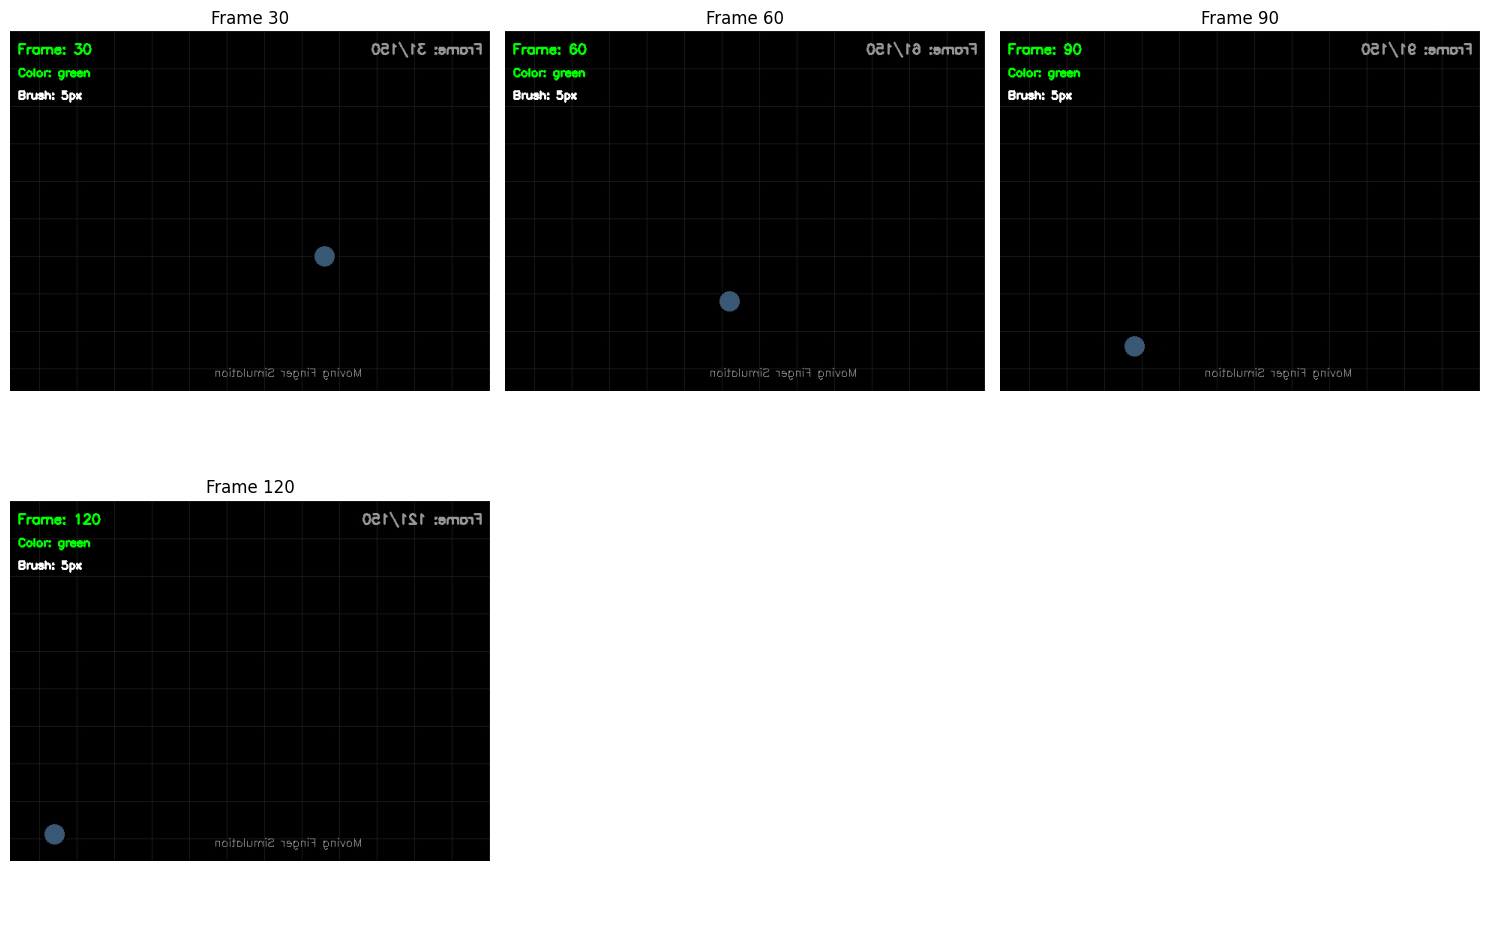

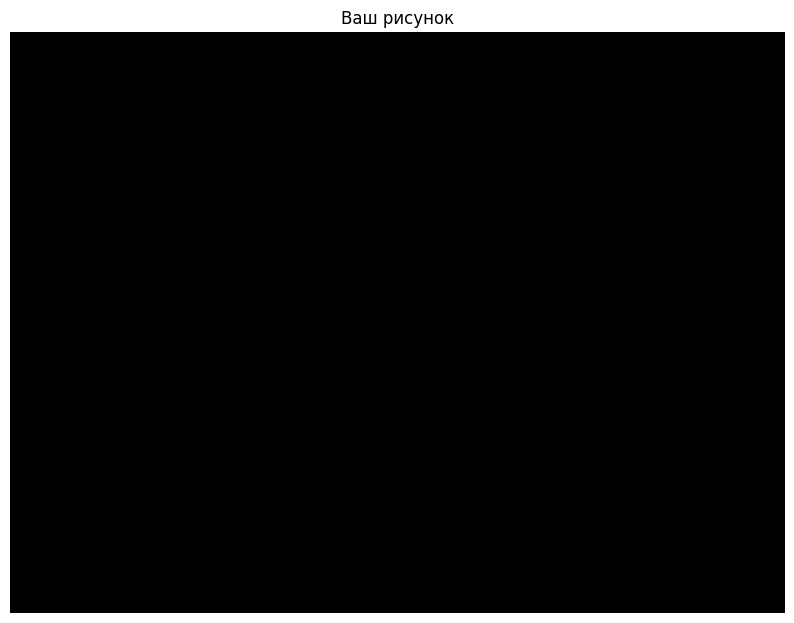

Рисунок сохранен: virtual_drawings\drawing_20260401_140242.jpg
Сохранено кадров: 4


In [28]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import math
from collections import deque
import time
import os

# ============================================
# 0. ПОДГОТОВКА
# ============================================

print("="*50)
print("ВИРТУАЛЬНАЯ КЛАВИАТУРА - Рисование в воздухе с отслеживанием пальца")
print("="*50)

# Создаем папку для сохранения рисунков
drawings_dir = 'virtual_drawings'
os.makedirs(drawings_dir, exist_ok=True)

# ============================================
# 1. КЛАСС ДЕТЕКТОРА ПАЛЬЦА (ИСПРАВЛЕННЫЙ)
# ============================================

class FingerTracker:
    """Класс для отслеживания пальца и рисования"""
    
    def __init__(self):
        # Диапазон цвета кожи в HSV
        self.skin_lower = np.array([0, 20, 70])
        self.skin_upper = np.array([20, 180, 255])
        
        # Параметры
        self.min_hand_area = 3000
        self.max_hand_area = 20000
        
        # Для рисования
        self.drawing_points = []  # Точки для рисования
        self.prev_point = None
        
        # Цвета
        self.current_color = (0, 255, 0)
        self.colors = {
            'red': (0, 0, 255),
            'green': (0, 255, 0),
            'blue': (255, 0, 0),
            'yellow': (0, 255, 255),
            'purple': (255, 0, 255),
            'cyan': (255, 255, 0),
            'white': (255, 255, 255)
        }
        self.color_names = list(self.colors.keys())
        self.current_color_idx = 1
        
        # Кисть
        self.brush_size = 5
        
        # Режимы
        self.mode = 'draw'
        
    def detect_finger(self, frame):
        """
        Находит кончик указательного пальца
        Возвращает: finger_pos, mask, hand_contour
        """
        # Конвертируем в HSV
        hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
        
        # Маска кожи
        mask = cv2.inRange(hsv, self.skin_lower, self.skin_upper)
        
        # Морфологическая очистка
        kernel = np.ones((5, 5), np.uint8)
        mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
        
        # Находим контуры
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
        if not contours:
            return None, mask, None
        
        # Находим самый большой контур
        hand_contour = max(contours, key=cv2.contourArea)
        area = cv2.contourArea(hand_contour)
        
        if area < self.min_hand_area or area > self.max_hand_area:
            return None, mask, hand_contour
        
        # Находим центр ладони
        M = cv2.moments(hand_contour)
        if M["m00"] != 0:
            palm_center = (int(M["m10"] / M["m00"]), int(M["m01"] / M["m00"]))
        else:
            palm_center = None
        
        # Находим самую верхнюю точку (кончик пальца)
        finger_pos = None
        if palm_center:
            # Находим точки выше центра
            points = hand_contour.squeeze()
            if len(points.shape) == 2:
                above_points = [tuple(p) for p in points if p[1] < palm_center[1] - 30]
                if above_points:
                    finger_pos = min(above_points, key=lambda p: p[1])
        
        return finger_pos, mask, hand_contour
    
    def update_drawing(self, finger_pos):
        """Обновляет рисование"""
        if finger_pos is None:
            self.prev_point = None
            return
        
        if self.mode == 'draw':
            if self.prev_point is not None:
                self.drawing_points.append((self.prev_point, finger_pos))
            self.prev_point = finger_pos
    
    def clear_drawing(self):
        """Очищает рисунок"""
        self.drawing_points = []
        self.prev_point = None
    
    def change_color(self):
        """Изменяет цвет"""
        self.current_color_idx = (self.current_color_idx + 1) % len(self.color_names)
        self.current_color = self.colors[self.color_names[self.current_color_idx]]
        return self.color_names[self.current_color_idx]
    
    def change_brush_size(self, delta=1):
        """Изменяет размер кисти"""
        self.brush_size = max(2, min(20, self.brush_size + delta))
        return self.brush_size

# ============================================
# 2. КЛАСС ДЛЯ РАБОТЫ БЕЗ GUI
# ============================================

class VirtualDrawingAppNoGUI:
    """Приложение для рисования без GUI (для Jupyter/Colab)"""
    
    def __init__(self):
        self.tracker = FingerTracker()
        self.canvas = None
        self.frame_count = 0
        self.captured_frames = []
        self.max_frames = 100
        
    def process_video(self, video_source=0, duration=10):
        """
        Обрабатывает видео и сохраняет результаты
        video_source: путь к видео или 0 для веб-камеры
        duration: длительность в секундах
        """
        # Открываем видео
        if isinstance(video_source, int):
            cap = cv2.VideoCapture(video_source)
            print(f"Захват с веб-камеры... Длительность: {duration} сек")
            start_time = time.time()
            use_webcam = True
        else:
            cap = cv2.VideoCapture(video_source)
            print(f"Обработка видео: {video_source}")
            use_webcam = False
        
        if not cap.isOpened():
            print("Ошибка: не удалось открыть источник видео")
            return
        
        # Получаем размеры
        ret, frame = cap.read()
        if ret:
            h, w = frame.shape[:2]
            self.canvas = np.zeros((h, w, 3), dtype=np.uint8)
        else:
            print("Ошибка: не удалось прочитать кадр")
            return
        
        print("Обработка видео...")
        
        try:
            while True:
                ret, frame = cap.read()
                if not ret:
                    break
                
                self.frame_count += 1
                
                # Для веб-камеры проверяем время
                if use_webcam and time.time() - start_time > duration:
                    break
                
                # Зеркальное отражение
                frame = cv2.flip(frame, 1)
                
                # Обнаруживаем палец
                finger_pos, mask, hand_contour = self.tracker.detect_finger(frame)
                
                # Обновляем рисование
                self.tracker.update_drawing(finger_pos)
                
                # Рисуем на канве
                canvas_result = self.draw_on_canvas()
                
                # Создаем результат
                result = cv2.addWeighted(frame, 0.6, canvas_result, 0.4, 0)
                
                # Отображаем палец
                if finger_pos:
                    cv2.circle(result, finger_pos, self.tracker.brush_size, 
                              self.tracker.current_color, -1)
                
                # Добавляем информацию
                cv2.putText(result, f"Frame: {self.frame_count}", (10, 30),
                           cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
                cv2.putText(result, f"Color: {self.tracker.color_names[self.tracker.current_color_idx]}", 
                           (10, 60), cv2.FONT_HERSHEY_SIMPLEX, 0.5, self.tracker.current_color, 2)
                cv2.putText(result, f"Brush: {self.tracker.brush_size}px", (10, 90),
                           cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 2)
                
                # Сохраняем каждый 30-й кадр
                if self.frame_count % 30 == 0:
                    self.captured_frames.append(result.copy())
                
                # Ограничиваем количество
                if len(self.captured_frames) > 10:
                    self.captured_frames.pop(0)
                
                # Прогресс
                if self.frame_count % 50 == 0:
                    print(f"Обработано кадров: {self.frame_count}")
                
        except KeyboardInterrupt:
            print("\nОстановка пользователем")
        finally:
            cap.release()
            print(f"\nОбработка завершена. Всего кадров: {self.frame_count}")
    
    def draw_on_canvas(self):
        """Рисует на канве сохраненные линии"""
        canvas = self.canvas.copy()
        
        for (p1, p2) in self.tracker.drawing_points:
            cv2.line(canvas, p1, p2, self.tracker.current_color, self.tracker.brush_size)
        
        return canvas
    
    def save_drawing(self, filename=None):
        """Сохраняет текущий рисунок"""
        if filename is None:
            timestamp = time.strftime("%Y%m%d_%H%M%S")
            filename = os.path.join(drawings_dir, f'drawing_{timestamp}.jpg')
        
        cv2.imwrite(filename, self.canvas)
        print(f"Рисунок сохранен: {filename}")
        return filename
    
    def save_captured_frames(self):
        """Сохраняет захваченные кадры"""
        for i, frame in enumerate(self.captured_frames):
            filename = os.path.join(drawings_dir, f'frame_{i+1:03d}.jpg')
            cv2.imwrite(filename, frame)
        print(f"Сохранено кадров: {len(self.captured_frames)}")
    
    def show_results(self):
        """Показывает результаты в виде изображений"""
        if not self.captured_frames:
            print("Нет захваченных кадров")
            return
        
        n_frames = min(len(self.captured_frames), 6)
        fig, axes = plt.subplots(2, 3, figsize=(15, 10))
        
        for i in range(n_frames):
            row, col = i // 3, i % 3
            frame_rgb = cv2.cvtColor(self.captured_frames[i], cv2.COLOR_BGR2RGB)
            axes[row, col].imshow(frame_rgb)
            axes[row, col].set_title(f"Frame {i*30+30}")
            axes[row, col].axis('off')
        
        for i in range(n_frames, 6):
            row, col = i // 3, i % 3
            axes[row, col].axis('off')
        
        plt.tight_layout()
        plt.show()
    
    def show_canvas(self):
        """Показывает финальный рисунок"""
        if self.canvas is not None:
            canvas_rgb = cv2.cvtColor(self.canvas, cv2.COLOR_BGR2RGB)
            plt.figure(figsize=(10, 8))
            plt.imshow(canvas_rgb)
            plt.title("Ваш рисунок")
            plt.axis('off')
            plt.show()

# ============================================
# 3. СОЗДАНИЕ ТЕСТОВОГО ВИДЕО
# ============================================

def create_test_video():
    """Создает тестовое видео с движущимся объектом"""
    width, height = 640, 480
    total_frames = 150
    fps = 20
    
    fourcc = cv2.VideoWriter_fourcc(*'XVID')
    video_path = os.path.join(drawings_dir, 'test_video.avi')
    out = cv2.VideoWriter(video_path, fourcc, fps, (width, height))
    
    x_pos = 100
    y_pos = height // 2
    dx = 4
    dy = 2
    
    for i in range(total_frames):
        frame = np.zeros((height, width, 3), dtype=np.uint8)
        
        # Сетка
        for j in range(0, width, 50):
            cv2.line(frame, (j, 0), (j, height), (50, 50, 50), 1)
        for j in range(0, height, 50):
            cv2.line(frame, (0, j), (width, j), (50, 50, 50), 1)
        
        # Движущийся объект (имитация пальца)
        cv2.circle(frame, (x_pos, y_pos), 15, (200, 150, 100), -1)
        cv2.circle(frame, (x_pos, y_pos), 15, (0, 0, 0), 2)
        
        cv2.putText(frame, f"Frame: {i+1}/{total_frames}", (10, 30),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)
        cv2.putText(frame, "Moving Finger Simulation", (width//2 - 150, height - 20),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)
        
        x_pos += dx
        y_pos += dy
        
        if x_pos > width - 20 or x_pos < 20:
            dx = -dx
        if y_pos > height - 20 or y_pos < 20:
            dy = -dy
        
        out.write(frame)
    
    out.release()
    print(f"Тестовое видео создано: {video_path}")
    return video_path

# ============================================
# 4. ДЕМОНСТРАЦИЯ НА ТЕСТОВОМ ВИДЕО
# ============================================

def demonstrate_on_test_video():
    """Демонстрирует работу на тестовом видео"""
    print("\n" + "="*50)
    print("ДЕМОНСТРАЦИЯ НА ТЕСТОВОМ ВИДЕО")
    print("="*50)
    
    # Создаем тестовое видео
    video_path = create_test_video()
    
    # Создаем приложение
    app = VirtualDrawingAppNoGUI()
    
    # Обрабатываем видео
    app.process_video(video_path)
    
    # Показываем результаты
    if app.captured_frames:
        app.show_results()
    else:
        print("Нет захваченных кадров")
    
    app.show_canvas()
    
    # Сохраняем
    app.save_drawing()
    app.save_captured_frames()
    
    return app

# ============================================
# 5. КОНСОЛЬНАЯ ВЕРСИЯ (ДЛЯ ОБЫЧНОГО PYTHON)
# ============================================

def console_version():
    """Консольная версия для обычного Python"""
    print("\n" + "="*50)
    print("КОНСОЛЬНАЯ ВЕРСИЯ")
    print("="*50)
    print("\nУправление:")
    print("  - Покажите указательный палец для рисования")
    print("  - Нажмите 'c' - смена цвета")
    print("  - '+' - увеличить кисть")
    print("  - '-' - уменьшить кисть")
    print("  - 'r' - очистить")
    print("  - 's' - сохранить")
    print("  - 'q' - выход")
    print("="*50)
    
    cap = cv2.VideoCapture(0)
    if not cap.isOpened():
        print("Ошибка: не удалось открыть веб-камеру")
        return
    
    tracker = FingerTracker()
    canvas = None
    
    ret, frame = cap.read()
    if ret:
        h, w = frame.shape[:2]
        canvas = np.zeros((h, w, 3), dtype=np.uint8)
    
    print("\nЗапуск... Нажмите 'q' для выхода")
    
    try:
        while True:
            ret, frame = cap.read()
            if not ret:
                break
            
            frame = cv2.flip(frame, 1)
            
            # Обнаруживаем палец
            finger_pos, mask, hand = tracker.detect_finger(frame)
            
            # Обновляем рисование
            tracker.update_drawing(finger_pos)
            
            # Рисуем на канве
            for (p1, p2) in tracker.drawing_points:
                cv2.line(canvas, p1, p2, tracker.current_color, tracker.brush_size)
            
            # Создаем результат
            result = cv2.addWeighted(frame, 0.6, canvas, 0.4, 0)
            
            # Отображаем палец
            if finger_pos:
                cv2.circle(result, finger_pos, tracker.brush_size, tracker.current_color, -1)
            
            # Информация
            cv2.putText(result, f"Color: {tracker.color_names[tracker.current_color_idx]}", (10, 30),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.6, tracker.current_color, 2)
            cv2.putText(result, f"Brush: {tracker.brush_size}px", (10, 60),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)
            
            cv2.imshow('Virtual Drawing - Press Q to quit', result)
            
            key = cv2.waitKey(1) & 0xFF
            if key == ord('q'):
                break
            elif key == ord('c'):
                tracker.change_color()
                print(f"Цвет: {tracker.color_names[tracker.current_color_idx]}")
            elif key == ord('+'):
                tracker.change_brush_size(1)
                print(f"Размер кисти: {tracker.brush_size}")
            elif key == ord('-'):
                tracker.change_brush_size(-1)
                print(f"Размер кисти: {tracker.brush_size}")
            elif key == ord('r'):
                tracker.clear_drawing()
                canvas = np.zeros_like(canvas)
                print("Рисунок очищен")
            elif key == ord('s'):
                timestamp = time.strftime("%Y%m%d_%H%M%S")
                filename = os.path.join(drawings_dir, f'drawing_{timestamp}.jpg')
                cv2.imwrite(filename, canvas)
                print(f"Рисунок сохранен: {filename}")
    
    except KeyboardInterrupt:
        print("\nОстановка пользователем")
    finally:
        cap.release()
        cv2.destroyAllWindows()

# ============================================
# 6. ЗАПУСК
# ============================================

def main():
    """Главная функция"""
    print("="*50)
    print("ВИРТУАЛЬНАЯ КЛАВИАТУРА - Рисование в воздухе")
    print("="*50)
    print("\nВыберите режим:")
    print("1 - Демонстрация на тестовом видео (без веб-камеры)")
    print("2 - Консольная версия с веб-камерой (для обычного Python)")
    
    choice = input("\nВаш выбор (1 или 2): ")
    
    if choice == '1':
        demonstrate_on_test_video()
    elif choice == '2':
        console_version()
    else:
        print("Неверный выбор, запускаем демонстрацию...")
        demonstrate_on_test_video()

if __name__ == "__main__":
    main()

## Пульсометр: измерение пульса по изменению цвета лица на видео

In [30]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import time
import os
from collections import deque
import scipy.signal as signal
import warnings
warnings.filterwarnings('ignore')

# ============================================
# 0. ПОДГОТОВКА
# ============================================

print("="*50)
print("ПУЛЬСОМЕТР - Измерение пульса по изменению цвета лица")
print("="*50)

# Создаем папку для сохранения результатов
results_dir = 'heart_rate_results'
os.makedirs(results_dir, exist_ok=True)

# ============================================
# 1. КЛАСС ПУЛЬСОМЕТРА
# ============================================

class HeartRateMonitor:
    """
    Класс для измерения пульса по видеопотоку
    Использует метод фотоплетизмографии (PPG)
    """
    
    def __init__(self, fps=30, window_size=150):
        """
        fps: частота кадров видео
        window_size: размер окна для анализа (кадров)
        """
        self.fps = fps
        self.window_size = window_size
        
        # Буферы для хранения данных
        self.signal_buffer = deque(maxlen=window_size)
        self.time_buffer = deque(maxlen=window_size)
        
        # Результаты
        self.heart_rate = 0
        self.heart_rate_history = deque(maxlen=10)
        self.quality = 0  # Качество сигнала (0-100)
        
        # Для фильтрации
        self.buffer = deque(maxlen=5)  # Для сглаживания
        
        print(f"Пульсометр инициализирован (FPS: {fps}, окно: {window_size} кадров)")
    
    def extract_roi_signal(self, face_roi):
        """
        Извлекает сигнал из области лица
        Использует среднее значение зеленого канала
        """
        # Конвертируем в RGB
        if len(face_roi.shape) == 3:
            # Берем зеленый канал (наиболее чувствителен к изменению кровотока)
            green_channel = face_roi[:, :, 1].astype(np.float32)
            
            # Вычисляем среднее значение зеленого канала
            mean_green = np.mean(green_channel)
            
            # Нормализуем
            return mean_green / 255.0
        
        return 0
    
    def update(self, face_roi, timestamp=None):
        """
        Обновляет пульсометр новым кадром
        """
        if timestamp is None:
            timestamp = time.time()
        
        # Извлекаем сигнал
        signal_value = self.extract_roi_signal(face_roi)
        
        # Добавляем в буфер
        self.signal_buffer.append(signal_value)
        self.time_buffer.append(timestamp)
        
        # Анализируем, если набралось достаточно данных
        if len(self.signal_buffer) > self.window_size // 2:
            self.analyze_signal()
        
        return signal_value
    
    def analyze_signal(self):
        """
        Анализирует сигнал для определения частоты пульса
        """
        if len(self.signal_buffer) < self.window_size // 2:
            return
        
        # Преобразуем в numpy массив
        signal_array = np.array(list(self.signal_buffer))
        
        # 1. Детренд (удаление тренда)
        signal_detrended = self.detrend_signal(signal_array)
        
        # 2. Фильтрация (0.8 - 3.0 Гц = 48-180 ударов/мин)
        filtered = self.filter_signal(signal_detrended)
        
        # 3. Спектральный анализ
        heart_rate, quality = self.find_peak_frequency(filtered)
        
        if heart_rate > 0:
            self.heart_rate = heart_rate
            self.heart_rate_history.append(heart_rate)
            self.quality = quality
            
            # Сглаживание
            if len(self.buffer) > 0:
                self.heart_rate = np.mean(self.buffer)
            self.buffer.append(heart_rate)
        
        return heart_rate
    
    def detrend_signal(self, signal):
        """
        Удаляет тренд из сигнала (медленные изменения)
        """
        # Простое вычитание скользящего среднего
        window = min(50, len(signal) // 3)
        if window < 3:
            return signal - np.mean(signal)
        
        # Скользящее среднее
        kernel = np.ones(window) / window
        trend = np.convolve(signal, kernel, mode='same')
        
        return signal - trend
    
    def filter_signal(self, signal):
        """
        Фильтрует сигнал в диапазоне частот пульса
        """
        # Простой полосовой фильтр через БПФ
        n = len(signal)
        if n < 10:
            return signal
        
        # Выполняем БПФ
        fft = np.fft.fft(signal)
        freqs = np.fft.fftfreq(n, d=1/self.fps)
        
        # Диапазон частот пульса: 0.8 - 3.0 Гц (48-180 ударов/мин)
        low_freq = 0.8
        high_freq = 3.0
        
        # Создаем маску
        mask = (np.abs(freqs) >= low_freq) & (np.abs(freqs) <= high_freq)
        fft_filtered = fft * mask
        
        # Обратное БПФ
        filtered = np.fft.ifft(fft_filtered).real
        
        return filtered
    
    def find_peak_frequency(self, signal):
        """
        Находит пиковую частоту в сигнале
        """
        n = len(signal)
        if n < 10:
            return 0, 0
        
        # Вычисляем спектр мощности
        fft = np.fft.fft(signal)
        power = np.abs(fft) ** 2
        freqs = np.fft.fftfreq(n, d=1/self.fps)
        
        # Берем только положительные частоты
        positive_mask = freqs > 0
        freqs_pos = freqs[positive_mask]
        power_pos = power[positive_mask]
        
        # Диапазон частот пульса (0.8 - 3.0 Гц)
        mask = (freqs_pos >= 0.8) & (freqs_pos <= 3.0)
        freqs_hr = freqs_pos[mask]
        power_hr = power_pos[mask]
        
        if len(power_hr) == 0:
            return 0, 0
        
        # Находим пик
        peak_idx = np.argmax(power_hr)
        peak_freq = freqs_hr[peak_idx]
        
        # Конвертируем в удары в минуту
        heart_rate = peak_freq * 60
        
        # Вычисляем качество сигнала (отношение пика к среднему)
        mean_power = np.mean(power_hr)
        peak_power = power_hr[peak_idx]
        quality = min(100, int(peak_power / mean_power * 100)) if mean_power > 0 else 0
        
        # Проверяем на реалистичность
        if 40 < heart_rate < 200:
            return heart_rate, quality
        
        return 0, 0
    
    def get_heart_rate(self):
        """Возвращает текущее значение пульса"""
        if self.heart_rate > 0:
            return int(self.heart_rate)
        return 0
    
    def get_quality(self):
        """Возвращает качество сигнала"""
        return self.quality
    
    def get_confidence(self):
        """Возвращает уровень уверенности"""
        if self.quality > 70:
            return "Высокий"
        elif self.quality > 40:
            return "Средний"
        else:
            return "Низкий"

# ============================================
# 2. КЛАСС ДЕТЕКТОРА ЛИЦ
# ============================================

class FaceDetector:
    """Класс для обнаружения лиц"""
    
    def __init__(self):
        self.face_cascade = cv2.CascadeClassifier(
            cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
        )
        self.eye_cascade = cv2.CascadeClassifier(
            cv2.data.haarcascades + 'haarcascade_eye.xml'
        )
    
    def detect_face(self, frame):
        """
        Обнаруживает лицо и возвращает область лица
        """
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        
        faces = self.face_cascade.detectMultiScale(
            gray,
            scaleFactor=1.1,
            minNeighbors=5,
            minSize=(100, 100)
        )
        
        if len(faces) > 0:
            # Берем самое большое лицо
            x, y, w, h = max(faces, key=lambda f: f[2] * f[3])
            
            # Область лица (лоб и щеки)
            roi_x = x + int(w * 0.2)
            roi_y = y + int(h * 0.2)
            roi_w = int(w * 0.6)
            roi_h = int(h * 0.5)
            
            face_roi = frame[roi_y:roi_y+roi_h, roi_x:roi_x+roi_w]
            
            return (x, y, w, h), (roi_x, roi_y, roi_w, roi_h), face_roi
        
        return None, None, None

# ============================================
# 3. КЛАСС ВИЗУАЛИЗАЦИИ
# ============================================

class HeartRateVisualizer:
    """Класс для визуализации результатов"""
    
    def __init__(self):
        self.signal_history = deque(maxlen=150)
        self.hr_history = deque(maxlen=30)
        
    def update(self, signal_value, heart_rate, quality):
        """Обновляет данные для визуализации"""
        self.signal_history.append(signal_value)
        self.hr_history.append(heart_rate)
    
    def draw_on_frame(self, frame, heart_rate, quality, confidence):
        """Рисует информацию на кадре"""
        result = frame.copy()
        h, w = result.shape[:2]
        
        # Фон для текста
        overlay = result.copy()
        cv2.rectangle(overlay, (10, 10), (250, 120), (0, 0, 0), -1)
        result = cv2.addWeighted(overlay, 0.6, result, 0.4, 0)
        
        # Значение пульса
        if heart_rate > 0:
            # Цвет в зависимости от пульса
            if heart_rate < 60:
                color = (255, 255, 0)  # Желтый - низкий
            elif heart_rate < 100:
                color = (0, 255, 0)    # Зеленый - норма
            else:
                color = (0, 0, 255)    # Красный - высокий
            
            cv2.putText(result, f"Heart Rate: {heart_rate} BPM", (20, 50),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2)
        else:
            cv2.putText(result, "Heart Rate: Measuring...", (20, 50),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
        
        # Качество сигнала
        cv2.putText(result, f"Signal Quality: {quality}% ({confidence})", (20, 85),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 0), 1)
        
        return result
    
    def plot_signal(self):
        """Отображает график сигнала"""
        if len(self.signal_history) < 10:
            return None
        
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))
        
        # Сигнал
        signal = np.array(list(self.signal_history))
        ax1.plot(signal, 'g-', linewidth=1.5)
        ax1.set_title('PPG Signal')
        ax1.set_xlabel('Frame')
        ax1.set_ylabel('Intensity')
        ax1.grid(True, alpha=0.3)
        
        # Гистограмма пульса
        hr_values = list(self.hr_history)
        if hr_values:
            ax2.plot(hr_values, 'r-', linewidth=2)
            ax2.set_title('Heart Rate History')
            ax2.set_xlabel('Measurement')
            ax2.set_ylabel('BPM')
            ax2.grid(True, alpha=0.3)
            ax2.set_ylim(40, 180)
        
        plt.tight_layout()
        return fig

# ============================================
# 4. ОСНОВНОЕ ПРИЛОЖЕНИЕ
# ============================================

class HeartRateApp:
    """Основное приложение пульсометра"""
    
    def __init__(self):
        self.face_detector = FaceDetector()
        self.heart_monitor = None
        self.visualizer = HeartRateVisualizer()
        
        self.recording = False
        self.recorded_frames = []
        self.recorded_signals = []
        
    def process_video(self, video_source=0, duration=30):
        """
        Обрабатывает видео и измеряет пульс
        video_source: 0 - веб-камера, или путь к видео
        duration: длительность записи (сек) для веб-камеры
        """
        # Открываем видео
        if isinstance(video_source, int):
            cap = cv2.VideoCapture(video_source)
            print(f"Запуск веб-камеры... Длительность: {duration} сек")
            start_time = time.time()
            use_webcam = True
        else:
            cap = cv2.VideoCapture(video_source)
            print(f"Обработка видео: {video_source}")
            use_webcam = False
        
        if not cap.isOpened():
            print("Ошибка: не удалось открыть источник видео")
            return
        
        # Получаем FPS
        fps = cap.get(cv2.CAP_PROP_FPS)
        if fps <= 0:
            fps = 30
        
        # Инициализируем пульсометр
        self.heart_monitor = HeartRateMonitor(fps=fps, window_size=int(fps * 5))
        
        frame_count = 0
        results = []
        
        print("\nИзмерение пульса...")
        print("Пожалуйста, смотрите в камеру и не двигайтесь")
        
        try:
            while True:
                ret, frame = cap.read()
                if not ret:
                    break
                
                frame_count += 1
                
                # Для веб-камеры проверяем время
                if use_webcam and time.time() - start_time > duration:
                    break
                
                # Зеркальное отражение для веб-камеры
                if use_webcam:
                    frame = cv2.flip(frame, 1)
                
                # Обнаруживаем лицо
                face_bbox, roi_bbox, face_roi = self.face_detector.detect_face(frame)
                
                if face_roi is not None and face_roi.size > 0:
                    # Обновляем пульсометр
                    signal_value = self.heart_monitor.update(face_roi)
                    heart_rate = self.heart_monitor.get_heart_rate()
                    quality = self.heart_monitor.get_quality()
                    confidence = self.heart_monitor.get_confidence()
                    
                    # Сохраняем для записи
                    self.recorded_signals.append(signal_value)
                    
                    # Обновляем визуализатор
                    self.visualizer.update(signal_value, heart_rate, quality)
                    
                    # Рисуем на кадре
                    result = self.visualizer.draw_on_frame(frame, heart_rate, quality, confidence)
                    
                    # Рисуем рамку вокруг лица
                    if face_bbox:
                        x, y, w, h = face_bbox
                        cv2.rectangle(result, (x, y), (x + w, y + h), (0, 255, 0), 2)
                    
                    # Рисуем область ROI
                    if roi_bbox:
                        rx, ry, rw, rh = roi_bbox
                        cv2.rectangle(result, (rx, ry), (rx + rw, ry + rh), (255, 255, 0), 1)
                    
                    # Выводим в консоль каждые 30 кадров
                    if frame_count % 30 == 0 and heart_rate > 0:
                        print(f"Кадр {frame_count}: Пульс = {heart_rate} BPM, Качество = {quality}%")
                        results.append(heart_rate)
                else:
                    result = frame
                    cv2.putText(result, "Face not detected", (20, 50),
                               cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)
                
                # Сохраняем кадры для записи
                if self.recording:
                    self.recorded_frames.append(result)
                
                # Показываем результат (если есть GUI)
                try:
                    cv2.imshow('Heart Rate Monitor - Press Q to quit', result)
                    key = cv2.waitKey(1) & 0xFF
                    if key == ord('q'):
                        break
                    elif key == ord('s'):
                        self.save_results()
                except:
                    # Если нет GUI, сохраняем кадры
                    if frame_count % 30 == 0:
                        filename = os.path.join(results_dir, f'frame_{frame_count}.jpg')
                        cv2.imwrite(filename, result)
                        print(f"Сохранен кадр: {filename}")
                
        except KeyboardInterrupt:
            print("\nОстановка пользователем")
        finally:
            cap.release()
            try:
                cv2.destroyAllWindows()
            except:
                pass
            
            print(f"\nИзмерение завершено. Обработано кадров: {frame_count}")
            
            # Показываем итоговые результаты
            self.show_summary(results)
            
            return results
    
    def save_results(self):
        """Сохраняет результаты"""
        timestamp = time.strftime("%Y%m%d_%H%M%S")
        
        # Сохраняем пульс
        hr = self.heart_monitor.get_heart_rate()
        quality = self.heart_monitor.get_quality()
        
        filename = os.path.join(results_dir, f'heart_rate_{timestamp}.txt')
        with open(filename, 'w', encoding='utf-8') as f:
            f.write(f"Результаты измерения пульса\n")
            f.write(f"="*40 + "\n")
            f.write(f"Время: {time.strftime('%Y-%m-%d %H:%M:%S')}\n")
            f.write(f"Пульс: {hr} BPM\n")
            f.write(f"Качество сигнала: {quality}%\n")
            f.write(f"Уверенность: {self.heart_monitor.get_confidence()}\n")
        
        print(f"Результаты сохранены: {filename}")
        
        # Сохраняем график
        fig = self.visualizer.plot_signal()
        if fig:
            plot_filename = os.path.join(results_dir, f'signal_plot_{timestamp}.png')
            fig.savefig(plot_filename)
            plt.close(fig)
            print(f"График сохранен: {plot_filename}")
    
    def show_summary(self, results):
        """Показывает итоговые результаты"""
        if not results:
            print("\nНедостаточно данных для определения пульса")
            return
        
        print("\n" + "="*50)
        print("ИТОГОВЫЕ РЕЗУЛЬТАТЫ")
        print("="*50)
        
        # Средний пульс
        avg_hr = np.mean(results[-20:]) if len(results) > 20 else np.mean(results)
        print(f"Средний пульс: {avg_hr:.0f} BPM")
        
        # Минимальный и максимальный
        print(f"Минимальный: {min(results):.0f} BPM")
        print(f"Максимальный: {max(results):.0f} BPM")
        
        # Стабильность
        std = np.std(results[-20:]) if len(results) > 20 else np.std(results)
        print(f"Стабильность: {std:.1f} BPM")
        
        # Оценка
        if avg_hr < 60:
            print("Оценка: Брадикардия (низкий пульс)")
        elif avg_hr < 100:
            print("Оценка: Нормальный пульс")
        else:
            print("Оценка: Тахикардия (высокий пульс)")
        
        # Сохраняем итоги
        self.save_results()

# ============================================
# 5. СОЗДАНИЕ ТЕСТОВОГО СИГНАЛА
# ============================================

def create_test_signal():
    """Создает тестовый сигнал пульса для демонстрации"""
    fps = 30
    duration = 30  # секунд
    heart_rate = 75  # ударов в минуту
    
    t = np.linspace(0, duration, int(fps * duration))
    
    # Основная частота
    freq = heart_rate / 60
    signal = np.sin(2 * np.pi * freq * t)
    
    # Добавляем гармоники
    signal += 0.3 * np.sin(4 * np.pi * freq * t)
    signal += 0.1 * np.sin(6 * np.pi * freq * t)
    
    # Добавляем шум
    signal += 0.2 * np.random.randn(len(t))
    
    # Добавляем тренд
    signal += 0.1 * np.linspace(0, 1, len(t))
    
    # Нормализуем
    signal = (signal - np.min(signal)) / (np.max(signal) - np.min(signal))
    
    return signal, heart_rate

def demonstrate_with_test_signal():
    """Демонстрация на тестовом сигнале"""
    print("\n" + "="*50)
    print("ДЕМОНСТРАЦИЯ НА ТЕСТОВОМ СИГНАЛЕ")
    print("="*50)
    
    # Создаем тестовый сигнал
    signal, true_hr = create_test_signal()
    
    # Создаем пульсометр
    monitor = HeartRateMonitor(fps=30, window_size=150)
    
    # Обрабатываем сигнал
    heart_rates = []
    
    for i, value in enumerate(signal):
        # Симулируем получение кадра
        monitor.signal_buffer.append(value)
        monitor.time_buffer.append(i / 30)
        
        if len(monitor.signal_buffer) > 75:
            monitor.analyze_signal()
            hr = monitor.get_heart_rate()
            if hr > 0:
                heart_rates.append(hr)
    
    # Визуализируем результаты
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
    
    # Исходный сигнал
    ax1.plot(signal, 'b-', linewidth=1, alpha=0.7, label='PPG Signal')
    ax1.set_title('Тестовый PPG сигнал (пульс: {:.0f} BPM)'.format(true_hr))
    ax1.set_xlabel('Кадры')
    ax1.set_ylabel('Амплитуда')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Измеренный пульс
    if heart_rates:
        ax2.plot(heart_rates, 'r-', linewidth=2, label='Измеренный пульс')
        ax2.axhline(y=true_hr, color='g', linestyle='--', label='Истинный пульс')
        ax2.set_title('Результаты измерения пульса')
        ax2.set_xlabel('Измерение')
        ax2.set_ylabel('BPM')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
        ax2.set_ylim(40, 120)
        
        avg_hr = np.mean(heart_rates[-20:])
        print(f"\nРезультаты теста:")
        print(f"  Истинный пульс: {true_hr:.0f} BPM")
        print(f"  Измеренный пульс: {avg_hr:.0f} BPM")
        print(f"  Ошибка: {abs(avg_hr - true_hr):.1f} BPM")
    
    plt.tight_layout()
    plt.savefig(os.path.join(results_dir, 'test_signal_analysis.png'))
    plt.show()
    
    return heart_rates

# ============================================
# 6. ЗАПУСК
# ============================================

def main():
    """Главная функция"""
    print("="*50)
    print("ПУЛЬСОМЕТР - Измерение пульса по видео")
    print("="*50)
    print("\nВыберите режим:")
    print("1 - Тест на синтетическом сигнале (демонстрация)")
    print("2 - Реальное измерение с веб-камерой")
    print("3 - Анализ видеофайла")
    
    choice = input("\nВаш выбор (1, 2 или 3): ")
    
    if choice == '1':
        demonstrate_with_test_signal()
    elif choice == '2':
        app = HeartRateApp()
        app.process_video(0, duration=30)
    elif choice == '3':
        video_path = input("Введите путь к видеофайлу: ")
        if os.path.exists(video_path):
            app = HeartRateApp()
            app.process_video(video_path)
        else:
            print("Файл не найден")
    else:
        print("Неверный выбор, запускаем демонстрацию...")
        demonstrate_with_test_signal()

if __name__ == "__main__":
    main()

ПУЛЬСОМЕТР - Измерение пульса по изменению цвета лица
ПУЛЬСОМЕТР - Измерение пульса по видео

Выберите режим:
1 - Тест на синтетическом сигнале (демонстрация)
2 - Реальное измерение с веб-камерой
3 - Анализ видеофайла
Файл не найден


## Анализ дорожного движения: подсчет машин и определение скорости

In [33]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import time
from collections import deque, defaultdict
import math
import json

# ============================================
# 0. ПОДГОТОВКА
# ============================================

print("="*50)
print("АНАЛИЗ ДОРОЖНОГО ДВИЖЕНИЯ - Подсчет машин и определение скорости")
print("="*50)

# Создаем папку для сохранения результатов
results_dir = 'traffic_analysis_results'
os.makedirs(results_dir, exist_ok=True)

# ============================================
# 1. КЛАСС ДЕТЕКТОРА ТРАНСПОРТА
# ============================================

class VehicleDetector:
    """
    Класс для обнаружения транспортных средств
    Использует вычитание фона и контуры
    """
    
    def __init__(self, min_area=1000, max_area=10000):
        """
        min_area: минимальная площадь объекта для обнаружения
        max_area: максимальная площадь объекта
        """
        self.min_area = min_area
        self.max_area = max_area
        
        # Создаем вычитатель фона
        self.bg_subtractor = cv2.createBackgroundSubtractorMOG2(
            history=500,
            varThreshold=16,
            detectShadows=True
        )
        
        # Параметры для фильтрации
        self.kernel = np.ones((5, 5), np.uint8)
        
        print(f"Детектор транспорта инициализирован (мин. площадь: {min_area}px)")
    
    def detect_vehicles(self, frame):
        """
        Обнаруживает транспортные средства на кадре
        Возвращает список обнаруженных объектов
        """
        # Применяем вычитание фона
        fgmask = self.bg_subtractor.apply(frame)
        
        # Удаляем тени
        _, fgmask = cv2.threshold(fgmask, 200, 255, cv2.THRESH_BINARY)
        
        # Морфологическая очистка
        fgmask = cv2.morphologyEx(fgmask, cv2.MORPH_OPEN, self.kernel)
        fgmask = cv2.morphologyEx(fgmask, cv2.MORPH_CLOSE, self.kernel)
        
        # Находим контуры
        contours, _ = cv2.findContours(fgmask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
        vehicles = []
        for contour in contours:
            area = cv2.contourArea(contour)
            
            if self.min_area < area < self.max_area:
                x, y, w, h = cv2.boundingRect(contour)
                
                # Соотношение сторон (автомобили обычно шире, чем выше)
                aspect_ratio = w / h if h > 0 else 0
                
                # Фильтруем по форме
                if 1.5 < aspect_ratio < 4.0:
                    vehicles.append({
                        'bbox': (x, y, w, h),
                        'center': (x + w//2, y + h//2),
                        'area': area,
                        'aspect_ratio': aspect_ratio
                    })
        
        return vehicles, fgmask
    
    def draw_detections(self, frame, vehicles):
        """Рисует обнаруженные автомобили"""
        result = frame.copy()
        
        for i, v in enumerate(vehicles):
            x, y, w, h = v['bbox']
            cv2.rectangle(result, (x, y), (x + w, y + h), (0, 255, 0), 2)
            cv2.putText(result, f"Vehicle {i+1}", (x, y - 5),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)
        
        return result

# ============================================
# 2. КЛАСС ТРЕКЕРА ОБЪЕКТОВ
# ============================================

class VehicleTracker:
    """
    Класс для отслеживания транспортных средств
    Использует сопоставление по расстоянию
    """
    
    def __init__(self, max_distance=50, max_age=10):
        """
        max_distance: максимальное расстояние для сопоставления объектов
        max_age: максимальный возраст трека без обновления
        """
        self.max_distance = max_distance
        self.max_age = max_age
        
        self.tracks = {}  # {track_id: track_info}
        self.next_id = 0
        
        # Для хранения траекторий
        self.trajectories = defaultdict(lambda: deque(maxlen=50))
        
        # Для подсчета скорости
        self.pixels_per_meter = 10  # Калибровка (пикселей на метр)
        self.fps = 30
        
    def update(self, vehicles, frame_number):
        """
        Обновляет треки новыми обнаружениями
        """
        # Сопоставляем новые объекты с существующими треками
        matches = self.match_vehicles(vehicles)
        
        # Обновляем существующие треки
        updated_tracks = set()
        for track_id, vehicle in matches:
            self.tracks[track_id]['last_seen'] = frame_number
            self.tracks[track_id]['positions'].append(vehicle['center'])
            self.tracks[track_id]['bbox'] = vehicle['bbox']
            self.tracks[track_id]['area'] = vehicle['area']
            updated_tracks.add(track_id)
            
            # Сохраняем траекторию
            self.trajectories[track_id].append(vehicle['center'])
        
        # Создаем новые треки для не сопоставленных объектов
        for i, vehicle in enumerate(vehicles):
            matched = False
            for track_id, v in matches:
                if v['center'] == vehicle['center']:
                    matched = True
                    break
            if not matched:
                self.tracks[self.next_id] = {
                    'id': self.next_id,
                    'positions': [vehicle['center']],
                    'bbox': vehicle['bbox'],
                    'area': vehicle['area'],
                    'first_seen': frame_number,
                    'last_seen': frame_number,
                    'active': True
                }
                self.trajectories[self.next_id].append(vehicle['center'])
                self.next_id += 1
        
        # Удаляем старые треки
        to_remove = []
        for track_id, track in self.tracks.items():
            if frame_number - track['last_seen'] > self.max_age:
                to_remove.append(track_id)
        
        for track_id in to_remove:
            del self.tracks[track_id]
            if track_id in self.trajectories:
                del self.trajectories[track_id]
        
        return self.tracks
    
    def match_vehicles(self, vehicles):
        """
        Сопоставляет новые объекты с существующими треками
        Использует евклидово расстояние
        """
        matches = []
        
        for track_id, track in self.tracks.items():
            if not track['active']:
                continue
            
            if not track['positions']:
                continue
            
            last_pos = track['positions'][-1]
            
            for vehicle in vehicles:
                dist = math.sqrt((last_pos[0] - vehicle['center'][0])**2 +
                                (last_pos[1] - vehicle['center'][1])**2)
                
                if dist < self.max_distance:
                    matches.append((track_id, vehicle))
                    break
        
        return matches
    
    def calculate_speed(self, track_id, pixels_per_meter=10, fps=30):
        """
        Вычисляет скорость автомобиля в км/ч
        """
        if track_id not in self.trajectories:
            return 0
        
        positions = list(self.trajectories[track_id])
        if len(positions) < 5:
            return 0
        
        # Вычисляем пройденное расстояние в пикселях
        total_distance_px = 0
        for i in range(1, len(positions)):
            dist = math.sqrt((positions[i][0] - positions[i-1][0])**2 +
                           (positions[i][1] - positions[i-1][1])**2)
            total_distance_px += dist
        
        # Время в секундах
        time_seconds = len(positions) / fps
        
        if time_seconds == 0:
            return 0
        
        # Скорость в пикселях/сек
        speed_px_per_sec = total_distance_px / time_seconds
        
        # Конвертируем в км/ч
        # Предполагаем, что 1 метр = pixels_per_meter пикселей
        speed_m_per_sec = speed_px_per_sec / pixels_per_meter
        speed_kmh = speed_m_per_sec * 3.6
        
        return speed_kmh
    
    def draw_tracks(self, frame):
        """Рисует траектории движения"""
        result = frame.copy()
        
        for track_id, track in self.tracks.items():
            if len(track['positions']) > 1:
                # Рисуем траекторию
                points = track['positions']
                for i in range(1, len(points)):
                    cv2.line(result, points[i-1], points[i], (0, 255, 255), 2)
                
                # Рисуем текущую позицию
                x, y, w, h = track['bbox']
                cv2.rectangle(result, (x, y), (x + w, y + h), (0, 255, 0), 2)
                
                # Добавляем ID
                cv2.putText(result, f"ID: {track_id}", (x, y - 5),
                           cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)
                
                # Добавляем скорость
                speed = self.calculate_speed(track_id)
                if speed > 0:
                    cv2.putText(result, f"{speed:.0f} km/h", (x, y + h + 15),
                               cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 255, 0), 1)
        
        return result

# ============================================
# 3. КЛАСС ПОДСЧЕТА МАШИН
# ============================================

class VehicleCounter:
    """
    Класс для подсчета машин, пересекающих линию
    """
    
    def __init__(self, line_position=0.5, direction='both'):
        """
        line_position: позиция линии подсчета (0-1)
        direction: 'both', 'left_to_right', 'right_to_left'
        """
        self.line_position = line_position
        self.direction = direction
        
        # Счетчики
        self.count_left_to_right = 0
        self.count_right_to_left = 0
        self.total_count = 0
        
        # Записанные пересечения
        self.crossed_vehicles = set()
    
    def update(self, tracks, frame_shape):
        """
        Обновляет счетчики на основе текущих треков
        """
        height, width = frame_shape[:2]
        line_y = int(height * self.line_position)
        
        for track_id, track in tracks.items():
            if track_id in self.crossed_vehicles:
                continue
            
            positions = track['positions']
            if len(positions) < 2:
                continue
            
            # Проверяем пересечение линии
            prev_y = positions[-2][1]
            curr_y = positions[-1][1]
            
            if (prev_y <= line_y <= curr_y) or (curr_y <= line_y <= prev_y):
                self.crossed_vehicles.add(track_id)
                
                # Определяем направление
                if curr_y > prev_y:  # Движение вниз (сверху вниз)
                    self.count_left_to_right += 1
                else:  # Движение вверх (снизу вверх)
                    self.count_right_to_left += 1
                
                self.total_count = self.count_left_to_right + self.count_right_to_left
    
    def draw_count_line(self, frame):
        """Рисует линию подсчета"""
        height, width = frame.shape[:2]
        line_y = int(height * self.line_position)
        
        cv2.line(frame, (0, line_y), (width, line_y), (0, 255, 255), 2)
        cv2.putText(frame, "COUNT LINE", (width - 120, line_y - 5),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 255), 1)
        
        return frame
    
    def draw_stats(self, frame):
        """Рисует статистику"""
        cv2.putText(frame, f"Total: {self.total_count}", (10, 30),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
        cv2.putText(frame, f"Left->Right: {self.count_left_to_right}", (10, 55),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 0), 1)
        cv2.putText(frame, f"Right->Left: {self.count_right_to_left}", (10, 80),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 0), 1)
        
        return frame
    
    def reset(self):
        """Сбрасывает счетчики"""
        self.count_left_to_right = 0
        self.count_right_to_left = 0
        self.total_count = 0
        self.crossed_vehicles.clear()

# ============================================
# 4. СОЗДАНИЕ ТЕСТОВОГО ВИДЕО
# ============================================

def create_test_traffic_video():
    """Создает тестовое видео с движущимися автомобилями"""
    width, height = 800, 600
    total_frames = 300
    fps = 20
    
    fourcc = cv2.VideoWriter_fourcc(*'XVID')
    video_path = os.path.join(results_dir, 'test_traffic.avi')
    out = cv2.VideoWriter(video_path, fourcc, fps, (width, height))
    
    # Параметры движения автомобилей
    cars = [
        {'x': 100, 'y': 200, 'dx': 3, 'color': (0, 0, 255), 'size': (60, 30)},
        {'x': 600, 'y': 350, 'dx': -2, 'color': (0, 255, 0), 'size': (60, 30)},
        {'x': 300, 'y': 450, 'dx': 4, 'color': (255, 0, 0), 'size': (60, 30)},
        {'x': 500, 'y': 150, 'dx': -3, 'color': (255, 255, 0), 'size': (60, 30)},
        {'x': 50, 'y': 500, 'dx': 2, 'color': (0, 255, 255), 'size': (60, 30)}
    ]
    
    for i in range(total_frames):
        # Фон
        frame = np.zeros((height, width, 3), dtype=np.uint8)
        
        # Дорога
        cv2.rectangle(frame, (0, height//2 - 100), (width, height//2 + 100), (100, 100, 100), -1)
        cv2.line(frame, (0, height//2), (width, height//2), (255, 255, 255), 2)
        
        # Разметка
        for x in range(0, width, 40):
            cv2.rectangle(frame, (x, height//2 - 2), (x + 20, height//2 + 2), (255, 255, 255), -1)
        
        # Рисуем автомобили
        for car in cars:
            x = car['x'] + car['dx'] * i
            y = car['y']
            w, h = car['size']
            
            # Ограничение по краям
            if x < 0:
                x = -w
            if x > width:
                x = width + w
            
            cv2.rectangle(frame, (int(x), y), (int(x + w), y + h), car['color'], -1)
            cv2.rectangle(frame, (int(x), y), (int(x + w), y + h), (255, 255, 255), 1)
        
        # Добавляем текст
        cv2.putText(frame, f"Frame: {i+1}/{total_frames}", (10, 30),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)
        cv2.putText(frame, "Traffic Analysis Test", (width//2 - 100, 50),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
        
        out.write(frame)
    
    out.release()
    print(f"Тестовое видео создано: {video_path}")
    return video_path

# ============================================
# 5. ОСНОВНОЕ ПРИЛОЖЕНИЕ
# ============================================

class TrafficAnalysisApp:
    """Основное приложение анализа трафика"""
    
    def __init__(self):
        self.detector = VehicleDetector(min_area=500, max_area=8000)
        self.tracker = VehicleTracker(max_distance=80, max_age=15)
        self.counter = VehicleCounter(line_position=0.5)
        
        self.pixels_per_meter = 20  # Калибровка
        self.fps = 30
        
        self.results = []
    
    def process_video(self, video_source=0, duration=30):
        """
        Обрабатывает видео и анализирует трафик
        """
        # Открываем видео
        if isinstance(video_source, int):
            cap = cv2.VideoCapture(video_source)
            print(f"Запуск веб-камеры... Длительность: {duration} сек")
            start_time = time.time()
            use_webcam = True
        else:
            cap = cv2.VideoCapture(video_source)
            print(f"Обработка видео: {video_source}")
            use_webcam = False
        
        if not cap.isOpened():
            print("Ошибка: не удалось открыть источник видео")
            return
        
        # Получаем FPS
        self.fps = cap.get(cv2.CAP_PROP_FPS)
        if self.fps <= 0:
            self.fps = 30
        
        # Настраиваем трекер
        self.tracker.fps = self.fps
        self.tracker.pixels_per_meter = self.pixels_per_meter
        
        frame_count = 0
        vehicle_counts = []
        
        print("\nАнализ дорожного движения...")
        print("Подсчет автомобилей и определение скорости")
        
        try:
            while True:
                ret, frame = cap.read()
                if not ret:
                    break
                
                frame_count += 1
                
                # Для веб-камеры проверяем время
                if use_webcam and time.time() - start_time > duration:
                    break
                
                # Зеркальное отражение для веб-камеры
                if use_webcam:
                    frame = cv2.flip(frame, 1)
                
                # Обнаруживаем автомобили
                vehicles, mask = self.detector.detect_vehicles(frame)
                
                # Обновляем трекер
                tracks = self.tracker.update(vehicles, frame_count)
                
                # Обновляем счетчик
                self.counter.update(tracks, frame.shape)
                
                # Рисуем результаты
                result = self.detector.draw_detections(frame, vehicles)
                result = self.tracker.draw_tracks(result)
                result = self.counter.draw_count_line(result)
                result = self.counter.draw_stats(result)
                
                # Добавляем информацию о скорости
                speeds = []
                for track_id, track in tracks.items():
                    speed = self.tracker.calculate_speed(track_id, self.pixels_per_meter, self.fps)
                    if speed > 0:
                        speeds.append(speed)
                
                if speeds:
                    avg_speed = np.mean(speeds)
                    cv2.putText(result, f"Avg Speed: {avg_speed:.0f} km/h", (10, 110),
                               cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 0), 1)
                
                # Сохраняем результаты
                if frame_count % 30 == 0:
                    vehicle_counts.append({
                        'frame': frame_count,
                        'count': len(vehicles),
                        'total': self.counter.total_count,
                        'avg_speed': np.mean(speeds) if speeds else 0
                    })
                
                # Показываем результат
                try:
                    cv2.imshow('Traffic Analysis - Press Q to quit', result)
                    cv2.imshow('Motion Mask', mask)
                    
                    key = cv2.waitKey(1) & 0xFF
                    if key == ord('q'):
                        break
                    elif key == ord('s'):
                        self.save_results()
                    elif key == ord('r'):
                        self.counter.reset()
                        print("Счетчик сброшен")
                except:
                    # Если нет GUI, сохраняем кадры
                    if frame_count % 30 == 0:
                        filename = os.path.join(results_dir, f'traffic_frame_{frame_count}.jpg')
                        cv2.imwrite(filename, result)
                        print(f"Сохранен кадр: {filename}")
                
        except KeyboardInterrupt:
            print("\nОстановка пользователем")
        finally:
            cap.release()
            try:
                cv2.destroyAllWindows()
            except:
                pass
            
            print(f"\nАнализ завершен. Обработано кадров: {frame_count}")
            
            # Показываем итоги
            self.show_summary(vehicle_counts)
            
            return vehicle_counts
    
    def save_results(self):
        """Сохраняет результаты анализа"""
        timestamp = time.strftime("%Y%m%d_%H%M%S")
        
        # Сохраняем статистику
        filename = os.path.join(results_dir, f'traffic_stats_{timestamp}.txt')
        with open(filename, 'w', encoding='utf-8') as f:
            f.write("Анализ дорожного движения\n")
            f.write("="*40 + "\n")
            f.write(f"Время: {time.strftime('%Y-%m-%d %H:%M:%S')}\n")
            f.write(f"Всего автомобилей: {self.counter.total_count}\n")
            f.write(f"Слева направо: {self.counter.count_left_to_right}\n")
            f.write(f"Справа налево: {self.counter.count_right_to_left}\n")
        
        print(f"Результаты сохранены: {filename}")
    
    def show_summary(self, vehicle_counts):
        """Показывает итоговые результаты"""
        if not vehicle_counts:
            print("\nНедостаточно данных для анализа")
            return
        
        print("\n" + "="*50)
        print("ИТОГИ АНАЛИЗА ДОРОЖНОГО ДВИЖЕНИЯ")
        print("="*50)
        print(f"Всего автомобилей: {self.counter.total_count}")
        print(f"Направление слева направо: {self.counter.count_left_to_right}")
        print(f"Направление справа налево: {self.counter.count_right_to_left}")
        
        # Средняя скорость
        speeds = []
        for track_id in self.tracker.tracks:
            speed = self.tracker.calculate_speed(track_id, self.pixels_per_meter, self.fps)
            if speed > 0:
                speeds.append(speed)
        
        if speeds:
            print(f"\nСредняя скорость: {np.mean(speeds):.0f} км/ч")
            print(f"Минимальная скорость: {np.min(speeds):.0f} км/ч")
            print(f"Максимальная скорость: {np.max(speeds):.0f} км/ч")
        
        # Интенсивность
        duration = len(vehicle_counts) * 30 / self.fps if vehicle_counts else 0
        intensity = self.counter.total_count / duration if duration > 0 else 0
        print(f"\nИнтенсивность: {intensity:.1f} автомобилей/сек ({intensity*60:.0f} авт/мин)")
        
        # Сохраняем итоги
        self.save_results()
        
        # Визуализируем результаты
        self.plot_results(vehicle_counts, speeds)
    
    def plot_results(self, vehicle_counts, speeds):
        """Визуализирует результаты"""
        fig, axes = plt.subplots(2, 2, figsize=(12, 10))
        
        # Количество автомобилей по кадрам
        frames = [vc['frame'] for vc in vehicle_counts]
        counts = [vc['count'] for vc in vehicle_counts]
        
        axes[0, 0].plot(frames, counts, 'b-', linewidth=2)
        axes[0, 0].set_title('Количество автомобилей на кадре')
        axes[0, 0].set_xlabel('Кадр')
        axes[0, 0].set_ylabel('Количество')
        axes[0, 0].grid(True, alpha=0.3)
        
        # Накопленный подсчет
        total = [vc['total'] for vc in vehicle_counts]
        axes[0, 1].plot(frames, total, 'g-', linewidth=2)
        axes[0, 1].set_title('Накопленное количество автомобилей')
        axes[0, 1].set_xlabel('Кадр')
        axes[0, 1].set_ylabel('Всего')
        axes[0, 1].grid(True, alpha=0.3)
        
        # Гистограмма скоростей
        if speeds:
            axes[1, 0].hist(speeds, bins=20, color='orange', alpha=0.7, edgecolor='black')
            axes[1, 0].set_title('Распределение скоростей')
            axes[1, 0].set_xlabel('Скорость (км/ч)')
            axes[1, 0].set_ylabel('Количество')
            axes[1, 0].grid(True, alpha=0.3)
        
        # Средняя скорость по времени
        avg_speeds = [vc['avg_speed'] for vc in vehicle_counts if vc['avg_speed'] > 0]
        if avg_speeds:
            axes[1, 1].plot(frames[:len(avg_speeds)], avg_speeds, 'r-', linewidth=2)
            axes[1, 1].set_title('Средняя скорость по времени')
            axes[1, 1].set_xlabel('Кадр')
            axes[1, 1].set_ylabel('Скорость (км/ч)')
            axes[1, 1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig(os.path.join(results_dir, 'traffic_analysis_plot.png'))
        plt.show()

# ============================================
# 6. ЗАПУСК
# ============================================

def main():
    """Главная функция"""
    print("="*50)
    print("АНАЛИЗ ДОРОЖНОГО ДВИЖЕНИЯ")
    print("="*50)
    print("\nВыберите режим:")
    print("1 - Тест на синтетическом видео")
    print("2 - Анализ видеофайла")
    print("3 - Реальный анализ с веб-камеры")
    
    choice = input("\nВаш выбор (1, 2 или 3): ")
    
    if choice == '1':
        video_path = create_test_traffic_video()
        app = TrafficAnalysisApp()
        app.process_video(video_path)
    elif choice == '2':
        video_path = input("Введите путь к видеофайлу: ")
        if os.path.exists(video_path):
            app = TrafficAnalysisApp()
            app.process_video(video_path)
        else:
            print("Файл не найден")
    elif choice == '3':
        app = TrafficAnalysisApp()
        app.process_video(0, duration=30)
    else:
        print("Неверный выбор, запускаем тест...")
        video_path = create_test_traffic_video()
        app = TrafficAnalysisApp()
        app.process_video(video_path)

if __name__ == "__main__":
    main()

АНАЛИЗ ДОРОЖНОГО ДВИЖЕНИЯ - Подсчет машин и определение скорости
АНАЛИЗ ДОРОЖНОГО ДВИЖЕНИЯ

Выберите режим:
1 - Тест на синтетическом видео
2 - Анализ видеофайла
3 - Реальный анализ с веб-камеры
Файл не найден


## Автоматическое создание аватара: обрезка лица и наложение эффектов

In [41]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import random
from tkinter import filedialog, Tk
import tkinter as tk
from tkinter import ttk, messagebox
from PIL import Image, ImageTk
import time

# ============================================
# 0. ПОДГОТОВКА
# ============================================

print("="*50)
print("АВТОМАТИЧЕСКОЕ СОЗДАНИЕ АВАТАРА - Обрезка лица и наложение эффектов")
print("="*50)

# Создаем папку для сохранения аватаров
avatars_dir = 'avatars'
os.makedirs(avatars_dir, exist_ok=True)

# ============================================
# 1. КЛАСС ДЕТЕКТОРА ЛИЦА
# ============================================

class FaceDetector:
    """Класс для обнаружения и обрезки лица"""
    
    def __init__(self):
        # Загружаем каскады Хаара
        cascade_path = cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
        print(f"Загрузка каскада: {cascade_path}")
        
        if os.path.exists(cascade_path):
            self.face_cascade = cv2.CascadeClassifier(cascade_path)
            print("✓ Каскад лиц загружен успешно")
        else:
            print("✗ Каскад лиц не найден")
            self.face_cascade = None
    
    def detect_face(self, image):
        """
        Обнаруживает лицо на изображении
        Возвращает: (x, y, w, h) координаты лица
        """
        if self.face_cascade is None:
            return None
        
        # Переводим в оттенки серого
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        
        # Обнаруживаем лица
        faces = self.face_cascade.detectMultiScale(
            gray,
            scaleFactor=1.1,
            minNeighbors=5,
            minSize=(50, 50),
            maxSize=(500, 500)
        )
        
        # Если не нашли, пробуем другие параметры
        if len(faces) == 0:
            faces = self.face_cascade.detectMultiScale(
                gray,
                scaleFactor=1.05,
                minNeighbors=3,
                minSize=(30, 30)
            )
        
        if len(faces) > 0:
            # Берем самое большое лицо
            x, y, w, h = max(faces, key=lambda f: f[2] * f[3])
            return (x, y, w, h)
        
        return None
    
    def crop_face(self, image, padding=0.2):
        """
        Обрезает изображение по лицу с отступами
        """
        face_bbox = self.detect_face(image)
        
        if face_bbox is None:
            return None, None
        
        x, y, w, h = face_bbox
        
        # Добавляем отступы
        pad_x = int(w * padding)
        pad_y = int(h * padding)
        
        # Координаты обрезки
        crop_x = max(0, x - pad_x)
        crop_y = max(0, y - pad_y)
        crop_w = min(image.shape[1] - crop_x, w + 2 * pad_x)
        crop_h = min(image.shape[0] - crop_y, h + 2 * pad_y)
        
        # Обрезаем
        face_cropped = image[crop_y:crop_y + crop_h, crop_x:crop_x + crop_w]
        
        return face_cropped, (crop_x, crop_y, crop_w, crop_h)

# ============================================
# 2. КЛАСС ЭФФЕКТОВ
# ============================================

class AvatarEffects:
    """Класс с эффектами для аватара"""
    
    @staticmethod
    def resize_to_square(image, size=512):
        """Изменяет размер изображения до квадрата"""
        if image is None:
            return None
            
        h, w = image.shape[:2]
        
        # Создаем квадратный холст
        square_size = max(h, w)
        canvas = np.zeros((square_size, square_size, 3), dtype=np.uint8)
        
        # Центрируем изображение
        y_offset = (square_size - h) // 2
        x_offset = (square_size - w) // 2
        canvas[y_offset:y_offset+h, x_offset:x_offset+w] = image
        
        # Изменяем размер
        result = cv2.resize(canvas, (size, size))
        
        return result
    
    @staticmethod
    def add_circle_mask(image, radius_factor=0.9):
        """Добавляет круглую маску"""
        if image is None:
            return None, None
            
        h, w = image.shape[:2]
        center = (w // 2, h // 2)
        radius = int(min(w, h) * radius_factor / 2)
        
        # Создаем маску
        mask = np.zeros((h, w), dtype=np.uint8)
        cv2.circle(mask, center, radius, 255, -1)
        
        # Применяем маску
        result = cv2.bitwise_and(image, image, mask=mask)
        
        return result, mask
    
    @staticmethod
    def add_border(image, border_size=10, color=(0, 255, 0)):
        """Добавляет рамку"""
        if image is None:
            return None
        return cv2.copyMakeBorder(image, border_size, border_size,
                                  border_size, border_size,
                                  cv2.BORDER_CONSTANT, value=color)
    
    @staticmethod
    def apply_cartoon_effect(image):
        """Мультяшный эффект"""
        if image is None:
            return None
            
        # Упрощение цветов
        color = cv2.bilateralFilter(image, 9, 300, 300)
        
        # Выделение границ
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        gray = cv2.medianBlur(gray, 5)
        edges = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_MEAN_C,
                                       cv2.THRESH_BINARY, 9, 9)
        
        # Комбинирование
        cartoon = cv2.bitwise_and(color, color, mask=edges)
        
        return cartoon
    
    @staticmethod
    def apply_sketch_effect(image):
        """Эффект карандашного рисунка"""
        if image is None:
            return None
            
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        inv = 255 - gray
        blur = cv2.GaussianBlur(inv, (21, 21), 0)
        sketch = cv2.divide(gray, 255 - blur, scale=256)
        
        return cv2.cvtColor(sketch, cv2.COLOR_GRAY2BGR)
    
    @staticmethod
    def apply_sepia(image):
        """Эффект сепии"""
        if image is None:
            return None
            
        sepia_matrix = np.array([[0.272, 0.534, 0.131],
                                  [0.349, 0.686, 0.168],
                                  [0.393, 0.769, 0.189]])
        result = cv2.transform(image, sepia_matrix)
        return np.clip(result, 0, 255).astype(np.uint8)
    
    @staticmethod
    def add_vignette(image, strength=0.5):
        """Эффект виньетки"""
        if image is None:
            return None
            
        rows, cols = image.shape[:2]
        kernel_x = cv2.getGaussianKernel(cols, cols/3)
        kernel_y = cv2.getGaussianKernel(rows, rows/3)
        kernel = kernel_y * kernel_x.T
        mask = kernel / kernel.max()
        
        result = image.copy().astype(np.float32)
        for i in range(3):
            result[:,:,i] = result[:,:,i] * (1 - (1 - mask) * strength)
        
        return result.astype(np.uint8)

# ============================================
# 3. КЛАСС АВАТАРА
# ============================================

class AvatarCreator:
    """Класс для создания аватара"""
    
    def __init__(self):
        self.face_detector = FaceDetector()
        self.effects = AvatarEffects()
        
        # Доступные эффекты
        self.available_effects = {
            'original': 'Оригинал',
            'cartoon': 'Мультяшный',
            'sketch': 'Карандаш',
            'sepia': 'Сепия',
            'vignette': 'Виньетка'
        }
        
        # Доступные рамки
        self.available_frames = {
            'none': 'Без рамки',
            'simple': 'Простая',
            'circle': 'Круглая'
        }
    
    def create_avatar(self, image, effect='original', frame='none', 
                     size=512, circle_mask=False):
        """
        Создает аватар из изображения
        """
        if image is None:
            return None, "Изображение не загружено"
        
        # 1. Обнаруживаем и обрезаем лицо
        face_cropped, crop_bbox = self.face_detector.crop_face(image, padding=0.2)
        
        if face_cropped is None:
            # Если лицо не найдено, используем центр изображения
            h, w = image.shape[:2]
            crop_size = min(h, w)
            crop_x = (w - crop_size) // 2
            crop_y = (h - crop_size) // 2
            face_cropped = image[crop_y:crop_y+crop_size, crop_x:crop_x+crop_size]
        
        # 2. Приводим к квадрату
        avatar = self.effects.resize_to_square(face_cropped, size)
        
        # 3. Применяем эффект
        if effect == 'cartoon':
            avatar = self.effects.apply_cartoon_effect(avatar)
        elif effect == 'sketch':
            avatar = self.effects.apply_sketch_effect(avatar)
        elif effect == 'sepia':
            avatar = self.effects.apply_sepia(avatar)
        elif effect == 'vignette':
            avatar = self.effects.add_vignette(avatar)
        
        # 4. Применяем круглую маску
        if circle_mask:
            avatar, _ = self.effects.add_circle_mask(avatar)
        
        # 5. Добавляем рамку
        if frame == 'simple':
            avatar = self.effects.add_border(avatar, 10, (0, 255, 0))
        elif frame == 'circle':
            avatar, _ = self.effects.add_circle_mask(avatar)
        
        return avatar, "Успешно создан"
    
    def create_random_avatar(self, image):
        """Создает аватар со случайными эффектами"""
        effect = random.choice(list(self.available_effects.keys()))
        frame = random.choice(list(self.available_frames.keys()))
        circle_mask = random.choice([True, False])
        
        return self.create_avatar(image, effect, frame, circle_mask=circle_mask)

# ============================================
# 4. ТЕСТОВАЯ ФУНКЦИЯ (ИСПРАВЛЕННАЯ)
# ============================================

def create_realistic_test_face():
    """Создает реалистичное тестовое лицо для детектора"""
    # Создаем изображение большего размера
    img = np.ones((800, 800, 3), dtype=np.uint8) * 240
    
    # Рисуем овал лица
    cv2.ellipse(img, (400, 400), (180, 220), 0, 0, 360, (200, 180, 150), -1)
    
    # Глаза (черные круги)
    cv2.circle(img, (340, 350), 25, (50, 50, 50), -1)
    cv2.circle(img, (460, 350), 25, (50, 50, 50), -1)
    cv2.circle(img, (340, 350), 12, (255, 255, 255), -1)
    cv2.circle(img, (460, 350), 12, (255, 255, 255), -1)
    cv2.circle(img, (340, 350), 6, (0, 0, 0), -1)
    cv2.circle(img, (460, 350), 6, (0, 0, 0), -1)
    
    # Нос
    cv2.line(img, (400, 380), (400, 440), (100, 80, 60), 5)
    
    # Рот
    cv2.ellipse(img, (400, 480), (50, 30), 0, 0, 180, (80, 60, 40), 3)
    
    # Брови
    cv2.line(img, (300, 310), (370, 320), (60, 50, 40), 8)
    cv2.line(img, (430, 320), (500, 310), (60, 50, 40), 8)
    
    # Добавляем контур
    cv2.ellipse(img, (400, 400), (180, 220), 0, 0, 360, (100, 80, 60), 2)
    
    return img

def test_avatar_creation():
    """Тестирует создание аватаров"""
    print("\n" + "="*50)
    print("ТЕСТИРОВАНИЕ СОЗДАНИЯ АВАТАРОВ")
    print("="*50)
    
    # Создаем реалистичное тестовое лицо
    test_img = create_realistic_test_face()
    
    # Сохраняем тестовое изображение
    test_path = os.path.join(avatars_dir, 'test_face.jpg')
    cv2.imwrite(test_path, test_img)
    print(f"Тестовое изображение сохранено: {test_path}")
    
    # Создаем аватар
    creator = AvatarCreator()
    
    # Проверяем детекцию лица
    face_bbox = creator.face_detector.detect_face(test_img)
    if face_bbox:
        print(f"✓ Лицо обнаружено: {face_bbox}")
        # Рисуем рамку на тестовом изображении
        x, y, w, h = face_bbox
        cv2.rectangle(test_img, (x, y), (x+w, y+h), (0, 255, 0), 3)
        cv2.imwrite(os.path.join(avatars_dir, 'face_detected.jpg'), test_img)
        print("  Изображение с рамкой сохранено: face_detected.jpg")
    else:
        print("✗ Лицо не обнаружено, будет использован центр изображения")
    
    # Создаем сетку 2x3
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    # Тестируем эффекты (первые 5 эффектов)
    effects = ['original', 'cartoon', 'sketch', 'sepia', 'vignette']
    
    for i, effect in enumerate(effects):
        row = i // 3
        col = i % 3
        avatar, msg = creator.create_avatar(test_img, effect=effect, size=300)
        if avatar is not None:
            axes[row, col].imshow(cv2.cvtColor(avatar, cv2.COLOR_BGR2RGB))
            axes[row, col].set_title(creator.available_effects[effect])
            axes[row, col].axis('off')
            # Сохраняем каждый аватар
            cv2.imwrite(os.path.join(avatars_dir, f'avatar_{effect}.jpg'), avatar)
            print(f"✓ Создан аватар: {effect}")
        else:
            axes[row, col].text(0.5, 0.5, f"Ошибка: {msg}", 
                               ha='center', va='center')
            axes[row, col].axis('off')
            print(f"✗ Ошибка при создании {effect}: {msg}")
    
    # Тестируем рамки (размещаем во второй строке, начиная с 0)
    frames = ['simple', 'circle']
    for i, frame in enumerate(frames):
        row = 1
        col = i  # i=0 для simple, i=1 для circle
        avatar, msg = creator.create_avatar(test_img, effect='original', 
                                            frame=frame, circle_mask=(frame=='circle'))
        if avatar is not None:
            axes[row, col].imshow(cv2.cvtColor(avatar, cv2.COLOR_BGR2RGB))
            axes[row, col].set_title(creator.available_frames[frame])
            axes[row, col].axis('off')
            cv2.imwrite(os.path.join(avatars_dir, f'avatar_frame_{frame}.jpg'), avatar)
            print(f"✓ Создан аватар с рамкой: {frame}")
        else:
            axes[row, col].text(0.5, 0.5, f"Ошибка: {msg}", 
                               ha='center', va='center')
            axes[row, col].axis('off')
            print(f"✗ Ошибка при создании {frame}: {msg}")
    
    # Для последнего пустого подграфика показываем исходное изображение
    axes[1, 2].imshow(cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB))
    axes[1, 2].set_title("Исходное изображение")
    axes[1, 2].axis('off')
    
    plt.tight_layout()
    plt.savefig(os.path.join(avatars_dir, 'test_avatars.png'))
    plt.show()
    
    print("\n" + "="*50)
    print(f"Все аватары сохранены в папку: {avatars_dir}")
    print("="*50)

# ============================================
# 5. ГРАФИЧЕСКИЙ ИНТЕРФЕЙС
# ============================================

class AvatarApp:
    """Приложение для создания аватаров"""
    
    def __init__(self, root):
        self.root = root
        self.root.title("Avatar Creator - Создание аватара")
        self.root.geometry("1200x700")
        self.root.configure(bg='#2c3e50')
        
        self.avatar_creator = AvatarCreator()
        self.original_image = None
        self.current_avatar = None
        self.image_path = None
        
        self.setup_ui()
        
        # Загружаем тестовое изображение
        self.load_test_image()
    
    def setup_ui(self):
        """Создает интерфейс"""
        
        # Верхняя панель
        toolbar = ttk.Frame(self.root)
        toolbar.pack(fill=tk.X, padx=10, pady=10)
        
        ttk.Button(toolbar, text="📁 Загрузить фото", 
                  command=self.load_image).pack(side=tk.LEFT, padx=5)
        ttk.Button(toolbar, text="🖼️ Тестовое фото", 
                  command=self.load_test_image).pack(side=tk.LEFT, padx=5)
        ttk.Button(toolbar, text="🎲 Случайный аватар", 
                  command=self.create_random).pack(side=tk.LEFT, padx=5)
        ttk.Button(toolbar, text="💾 Сохранить", 
                  command=self.save_avatar).pack(side=tk.LEFT, padx=5)
        
        # Основная область
        main_frame = ttk.Frame(self.root)
        main_frame.pack(fill=tk.BOTH, expand=True, padx=10, pady=5)
        
        # Левая панель с настройками
        left_panel = ttk.Frame(main_frame, width=250)
        left_panel.pack(side=tk.LEFT, fill=tk.Y, padx=(0, 10))
        left_panel.pack_propagate(False)
        
        ttk.Label(left_panel, text="🎨 НАСТРОЙКИ", 
                 font=('Arial', 12, 'bold')).pack(pady=10)
        
        # Выбор эффекта
        ttk.Label(left_panel, text="Эффект:").pack(anchor='w', padx=10, pady=(10, 0))
        self.effect_var = tk.StringVar(value='Оригинал')
        effect_combo = ttk.Combobox(left_panel, textvariable=self.effect_var,
                                    values=list(self.avatar_creator.available_effects.values()),
                                    state='readonly')
        effect_combo.pack(fill=tk.X, padx=10, pady=5)
        effect_combo.bind('<<ComboboxSelected>>', self.update_avatar)
        
        # Выбор рамки
        ttk.Label(left_panel, text="Рамка:").pack(anchor='w', padx=10, pady=(10, 0))
        self.frame_var = tk.StringVar(value='Без рамки')
        frame_combo = ttk.Combobox(left_panel, textvariable=self.frame_var,
                                   values=list(self.avatar_creator.available_frames.values()),
                                   state='readonly')
        frame_combo.pack(fill=tk.X, padx=10, pady=5)
        frame_combo.bind('<<ComboboxSelected>>', self.update_avatar)
        
        # Круглая маска
        self.mask_var = tk.BooleanVar(value=False)
        ttk.Checkbutton(left_panel, text="Круглая маска", 
                       variable=self.mask_var,
                       command=self.update_avatar).pack(anchor='w', padx=10, pady=10)
        
        # Размер
        ttk.Label(left_panel, text="Размер:").pack(anchor='w', padx=10, pady=(10, 0))
        size_frame = ttk.Frame(left_panel)
        size_frame.pack(anchor='w', padx=10, pady=5)
        
        ttk.Button(size_frame, text="-", width=3, 
                  command=lambda: self.change_size(-64)).pack(side=tk.LEFT)
        self.size_var = tk.IntVar(value=300)
        self.size_label = ttk.Label(size_frame, text="300", width=10, anchor='center')
        self.size_label.pack(side=tk.LEFT, padx=5)
        ttk.Button(size_frame, text="+", width=3, 
                  command=lambda: self.change_size(64)).pack(side=tk.LEFT)
        
        # Кнопка применить
        ttk.Button(left_panel, text="🔄 Создать аватар", 
                  command=self.update_avatar).pack(fill=tk.X, padx=10, pady=20)
        
        # Информация
        self.info_label = ttk.Label(left_panel, text="Загрузите фото", 
                                     relief=tk.SUNKEN)
        self.info_label.pack(fill=tk.X, padx=10, pady=10)
        
        # Правая панель с изображениями
        right_panel = ttk.Frame(main_frame)
        right_panel.pack(side=tk.RIGHT, fill=tk.BOTH, expand=True)
        
        # Оригинал
        orig_frame = ttk.LabelFrame(right_panel, text="Оригинал")
        orig_frame.pack(side=tk.LEFT, fill=tk.BOTH, expand=True, padx=5)
        
        self.orig_label = ttk.Label(orig_frame, background='#34495e')
        self.orig_label.pack(fill=tk.BOTH, expand=True)
        
        # Аватар
        avatar_frame = ttk.LabelFrame(right_panel, text="Аватар")
        avatar_frame.pack(side=tk.RIGHT, fill=tk.BOTH, expand=True, padx=5)
        
        self.avatar_label = ttk.Label(avatar_frame, background='#34495e')
        self.avatar_label.pack(fill=tk.BOTH, expand=True)
        
        # Статус
        self.status_label = ttk.Label(self.root, text="Готов", relief=tk.SUNKEN)
        self.status_label.pack(fill=tk.X, padx=10, pady=10)
    
    def change_size(self, delta):
        """Изменяет размер аватара"""
        new_size = self.size_var.get() + delta
        if 128 <= new_size <= 1024:
            self.size_var.set(new_size)
            self.size_label.config(text=str(new_size))
            self.update_avatar()
    
    def load_image(self):
        """Загружает изображение из файла"""
        file_path = filedialog.askopenfilename(
            title="Выберите фото",
            filetypes=[("Image files", "*.jpg *.jpeg *.png *.bmp"), ("All files", "*.*")]
        )
        
        if file_path:
            try:
                self.original_image = cv2.imread(file_path)
                if self.original_image is None:
                    raise ValueError("Не удалось загрузить изображение")
                
                self.image_path = file_path
                self.update_display()
                self.status_label.config(text=f"Загружено: {os.path.basename(file_path)}")
                self.info_label.config(text="Фото загружено")
                
                # Автоматически создаем аватар
                self.update_avatar()
                
            except Exception as e:
                messagebox.showerror("Ошибка", f"Не удалось загрузить: {e}")
    
    def load_test_image(self):
        """Загружает тестовое изображение"""
        test_img = create_realistic_test_face()
        self.original_image = test_img
        self.update_display()
        self.status_label.config(text="Загружено тестовое изображение")
        self.info_label.config(text="Тестовое изображение")
        
        # Автоматически создаем аватар
        self.update_avatar()
    
    def update_avatar(self, event=None):
        """Обновляет аватар с текущими настройками"""
        if self.original_image is None:
            return
        
        # Получаем название эффекта
        effect_name = self.effect_var.get()
        frame_name = self.frame_var.get()
        
        # Преобразуем название в ключ
        effect_key = None
        for key, name in self.avatar_creator.available_effects.items():
            if name == effect_name:
                effect_key = key
                break
        
        frame_key = None
        for key, name in self.avatar_creator.available_frames.items():
            if name == frame_name:
                frame_key = key
                break
        
        self.status_label.config(text="Создание аватара...")
        self.root.update()
        
        avatar, message = self.avatar_creator.create_avatar(
            self.original_image,
            effect=effect_key if effect_key else 'original',
            frame=frame_key if frame_key else 'none',
            size=self.size_var.get(),
            circle_mask=self.mask_var.get()
        )
        
        if avatar is not None:
            self.current_avatar = avatar
            self.display_avatar(avatar)
            self.status_label.config(text=message)
        else:
            self.status_label.config(text=f"Ошибка: {message}")
    
    def create_random(self):
        """Создает случайный аватар"""
        if self.original_image is None:
            messagebox.showwarning("Предупреждение", "Сначала загрузите фото")
            return
        
        self.status_label.config(text="Создание случайного аватара...")
        self.root.update()
        
        avatar, message = self.avatar_creator.create_random_avatar(self.original_image)
        
        if avatar is not None:
            self.current_avatar = avatar
            self.display_avatar(avatar)
            self.status_label.config(text=f"Случайный аватар: {message}")
        else:
            messagebox.showerror("Ошибка", message)
    
    def save_avatar(self):
        """Сохраняет аватар"""
        if self.current_avatar is None:
            messagebox.showwarning("Предупреждение", "Нет аватара для сохранения")
            return
        
        timestamp = time.strftime("%Y%m%d_%H%M%S")
        filename = filedialog.asksaveasfilename(
            title="Сохранить аватар",
            defaultextension=".jpg",
            initialfile=f"avatar_{timestamp}.jpg",
            filetypes=[("JPEG", "*.jpg"), ("PNG", "*.png")]
        )
        
        if filename:
            cv2.imwrite(filename, self.current_avatar)
            self.status_label.config(text=f"Сохранено: {os.path.basename(filename)}")
            messagebox.showinfo("Успех", "Аватар сохранен!")
    
    def update_display(self):
        """Обновляет отображение оригинального изображения"""
        if self.original_image is not None:
            # Ограничиваем размер
            h, w = self.original_image.shape[:2]
            max_size = 400
            if max(h, w) > max_size:
                scale = max_size / max(h, w)
                new_w = int(w * scale)
                new_h = int(h * scale)
                display_img = cv2.resize(self.original_image, (new_w, new_h))
            else:
                display_img = self.original_image.copy()
            
            img_rgb = cv2.cvtColor(display_img, cv2.COLOR_BGR2RGB)
            pil_img = Image.fromarray(img_rgb)
            self.tk_orig = ImageTk.PhotoImage(pil_img)
            self.orig_label.configure(image=self.tk_orig)
    
    def display_avatar(self, avatar):
        """Отображает аватар"""
        # Ограничиваем размер
        h, w = avatar.shape[:2]
        max_size = 400
        if max(h, w) > max_size:
            scale = max_size / max(h, w)
            new_w = int(w * scale)
            new_h = int(h * scale)
            display_img = cv2.resize(avatar, (new_w, new_h))
        else:
            display_img = avatar.copy()
        
        img_rgb = cv2.cvtColor(display_img, cv2.COLOR_BGR2RGB)
        pil_img = Image.fromarray(img_rgb)
        self.tk_avatar = ImageTk.PhotoImage(pil_img)
        self.avatar_label.configure(image=self.tk_avatar)

# ============================================
# 6. ЗАПУСК
# ============================================

def main():
    """Главная функция"""
    print("="*50)
    print("АВТОМАТИЧЕСКОЕ СОЗДАНИЕ АВАТАРА")
    print("="*50)
    print("\nВыберите режим:")
    print("1 - Графический интерфейс")
    print("2 - Тестирование эффектов")
    
    choice = input("\nВаш выбор (1 или 2): ")
    
    if choice == '1':
        root = tk.Tk()
        app = AvatarApp(root)
        root.mainloop()
    elif choice == '2':
        test_avatar_creation()
    else:
        print("Неверный выбор, запускаем графический интерфейс...")
        root = tk.Tk()
        app = AvatarApp(root)
        root.mainloop()

if __name__ == "__main__":
    main()

АВТОМАТИЧЕСКОЕ СОЗДАНИЕ АВАТАРА - Обрезка лица и наложение эффектов
АВТОМАТИЧЕСКОЕ СОЗДАНИЕ АВАТАРА

Выберите режим:
1 - Графический интерфейс
2 - Тестирование эффектов
Загрузка каскада: c:\Users\master\AppData\Local\Programs\Python\Python313\Lib\site-packages\cv2\data\haarcascade_frontalface_default.xml
✓ Каскад лиц загружен успешно
